In [1]:
import numpy as np
from scipy.linalg import solve
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# Simulation
# -------------------------------
def simulate_ou_dfa(
    n_subjects=10,
    T_list=None,
    p=8000,
    k=5,
    rho_mean=0.05,
    rho_sd=0.03,
    Q_scale=0.3,
    Psi_scale=0.5,
    sparsity=0.7,
    shock_prob=0.05,
    shock_scale=3.0,
    random_state=42,
):
    """
    Harder OU-DFA simulation:
    - correlated latent OU dynamics
    - factor-specific decay
    - sparse & collinear loadings
    - heteroskedastic noise
    - latent shocks
    """
    rng = np.random.default_rng(random_state)

    if T_list is None:
        T_list = [10] * n_subjects

    # -----------------------
    # Loadings: sparse + collinear
    # -----------------------
    Lambda_true = rng.normal(0, 1, size=(p, k))

    mask = rng.uniform(size=(p, k)) > sparsity
    Lambda_true *= mask

    # induce collinearity
    if k > 1:
        Lambda_true[:, 1] += 0.8 * Lambda_true[:, 0]

    Lambda_true /= np.linalg.norm(Lambda_true, axis=0, keepdims=True)

    # -----------------------
    # Latent OU parameters
    # -----------------------
    rho = np.abs(rng.normal(rho_mean, rho_sd, size=k))

    # correlated innovation covariance
    R = rng.normal(size=(k, k))
    Q = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 10.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(0, 1, size=k)

        for t in range(1, T):
            A = np.diag(np.exp(-rho * dt[t - 1]))
            z[t] = A @ z[t - 1] + rng.multivariate_normal(np.zeros(k), Q)

            # latent shock (non-Gaussian)
            if rng.uniform() < shock_prob:
                z[t] += rng.normal(0, shock_scale, size=k)

        # heteroskedastic observation noise
        Psi_diag = Psi_scale * rng.lognormal(mean=0.0, sigma=0.5, size=p)
        noise = rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        y = z @ Lambda_true.T + noise

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda_true, dts_all

# -------------------------------
# Kalman Smoother (irregular dt)
# -------------------------------
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))

    R = Psi
    eps = 1e-5  # numeric stabilizer

    # Forward pass (Kalman filter)
    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q * np.eye(k)
            m = A @ m
        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P
        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz

# -------------------------------
# EM Updates
# -------------------------------
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    """
    Update factor loadings Lambda (p x k) with horseshoe shrinkage.
    Handles variable-length sequences (irregular visits).
    Ez_all: list of [T_i x k] latent expectations per subject
    Ezz_all: list of [T_i x k x k] latent covariances per subject
    Ys: list of [T_i x p] observations per subject
    tau, lam: shrinkage parameters (scalar or length-k)
    """
    p = Ys[0].shape[1]  # number of observed variables
    k = Ez_all[0].shape[1]  # number of factors

    # If tau or lam are scalars, broadcast to length k
    tau = np.full(k, tau) if np.isscalar(tau) else np.asarray(tau).reshape(k,)
    lam = np.full(k, lam) if np.isscalar(lam) else np.asarray(lam).reshape(k,)

    Lambda = np.zeros((p, k))

    # Compute sums over subjects and time
    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        T = Y.shape[0]
        for t in range(T):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    # Horseshoe ridge
    ridge = np.diag(1.0 / (tau * lam**2 + eps))

    # Solve for each observed dimension
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda



def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ez_all):
        T = Y.shape[0]
        for t in range(T):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1
    Psi = np.diag(num/den + eps)
    return Psi

# -------------------------------
# EM Loop (irregular dt)
# -------------------------------
def run_em(Ys, dts_all, k=3, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f}")

    return Lambda

# -------------------------------
# Factor recovery metric
# -------------------------------
def factor_recovery(L_true, L_est):
    # Procrustes alignment
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_true.ravel(), L_aligned.ravel())[0,1]
    return corr


Iter 00 | mean|Λ|=0.393 | MSE=0.7150
Iter 01 | mean|Λ|=0.313 | MSE=0.4824
Iter 02 | mean|Λ|=0.277 | MSE=0.4310
Iter 03 | mean|Λ|=0.254 | MSE=0.4172
Iter 04 | mean|Λ|=0.238 | MSE=0.4129
Iter 05 | mean|Λ|=0.228 | MSE=0.4144
Iter 06 | mean|Λ|=0.221 | MSE=0.4178
Iter 07 | mean|Λ|=0.216 | MSE=0.4207
Iter 08 | mean|Λ|=0.211 | MSE=0.4251
Iter 09 | mean|Λ|=0.206 | MSE=0.4301
Iter 10 | mean|Λ|=0.202 | MSE=0.4333
Iter 11 | mean|Λ|=0.198 | MSE=0.4347
Iter 12 | mean|Λ|=0.195 | MSE=0.4354
Iter 13 | mean|Λ|=0.191 | MSE=0.4360
Iter 14 | mean|Λ|=0.189 | MSE=0.4365
Iter 15 | mean|Λ|=0.186 | MSE=0.4370
Iter 16 | mean|Λ|=0.183 | MSE=0.4374
Iter 17 | mean|Λ|=0.181 | MSE=0.4378
Iter 18 | mean|Λ|=0.179 | MSE=0.4383
Iter 19 | mean|Λ|=0.176 | MSE=0.4387
Iter 20 | mean|Λ|=0.174 | MSE=0.4392
Iter 21 | mean|Λ|=0.172 | MSE=0.4396
Iter 22 | mean|Λ|=0.170 | MSE=0.4401
Iter 23 | mean|Λ|=0.168 | MSE=0.4405
Iter 24 | mean|Λ|=0.166 | MSE=0.4409
Iter 25 | mean|Λ|=0.164 | MSE=0.4413
Iter 26 | mean|Λ|=0.162 | MSE=0.4416
I

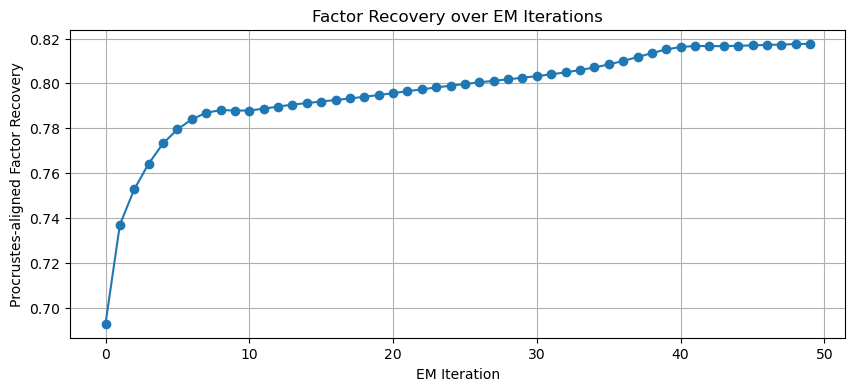

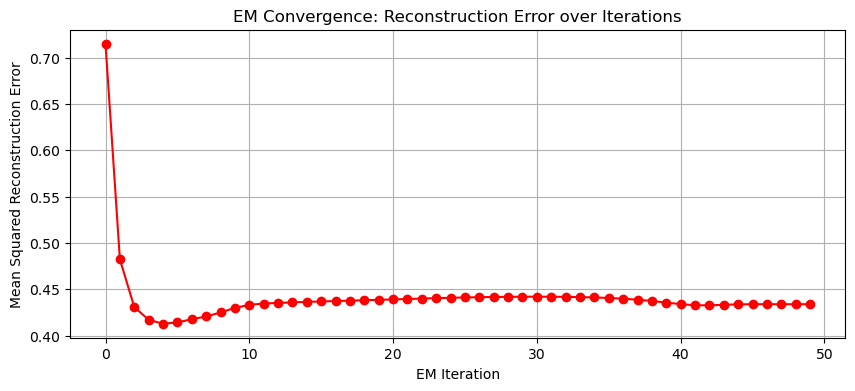

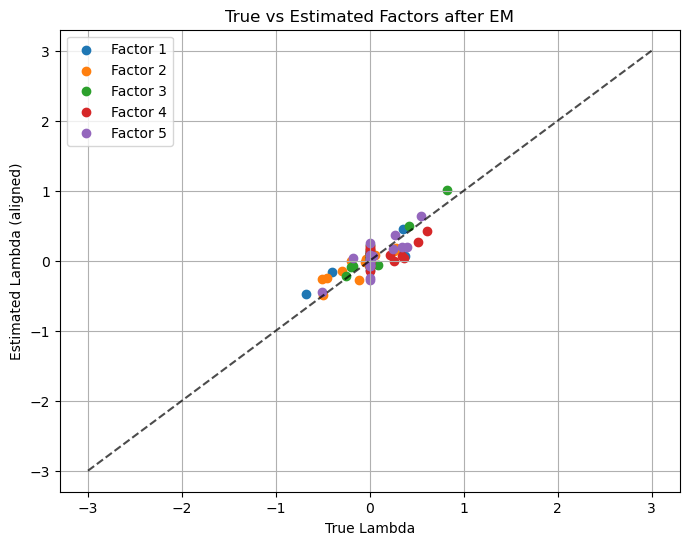

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# EM with history and reconstruction error
# -------------------------------
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    history_Lambda = []
    mean_abs_history = []
    recon_error_history = []

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        # Save history
        history_Lambda.append(Lambda.copy())
        mean_abs_history.append(np.mean(np.abs(Lambda)))

        # Compute mean squared reconstruction error
        mse = 0
        count = 0
        for Y, Ez in zip(Ys, Ezs):
            Y_hat = Ez @ Lambda.T
            mse += np.sum((Y - Y_hat)**2)
            count += Y.size
        recon_error_history.append(mse / count)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f} | MSE={recon_error_history[-1]:.4f}")

    return Lambda, history_Lambda, mean_abs_history, recon_error_history

# -------------------------------
# Visualization
# -------------------------------
def plot_em_performance(Lambda_true, history_Lambda, recon_error_history):
    n_iter = len(history_Lambda)
    k = Lambda_true.shape[1]

    # Factor recovery over iterations
    recovery = []
    for L_est in history_Lambda:
        R, _ = orthogonal_procrustes(L_est, Lambda_true)
        L_aligned = L_est @ R
        corr = np.corrcoef(Lambda_true.ravel(), L_aligned.ravel())[0,1]
        recovery.append(corr)

    # Plot factor recovery
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recovery, marker='o')
    plt.xlabel("EM Iteration")
    plt.ylabel("Procrustes-aligned Factor Recovery")
    plt.title("Factor Recovery over EM Iterations")
    plt.grid(True)
    plt.show()

    # Plot reconstruction error
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recon_error_history, marker='o', color='r')
    plt.xlabel("EM Iteration")
    plt.ylabel("Mean Squared Reconstruction Error")
    plt.title("EM Convergence: Reconstruction Error over Iterations")
    plt.grid(True)
    plt.show()

    # True vs Estimated factors (final)
    L_final = history_Lambda[-1]
    R, _ = orthogonal_procrustes(L_final, Lambda_true)
    L_aligned = L_final @ R

    plt.figure(figsize=(8,6))
    for i in range(k):
        plt.scatter(Lambda_true[:, i], L_aligned[:, i], label=f"Factor {i+1}")
    plt.plot([-3,3], [-3,3], 'k--', alpha=0.7)
    plt.xlabel("True Lambda")
    plt.ylabel("Estimated Lambda (aligned)")
    plt.title("True vs Estimated Factors after EM")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# Main
# -------------------------------
def main_vis():
    n_subjects = 10
    T_list = [5,4,6,5,7,4,5,6,5,5]  # irregular T per subject
    Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
        n_subjects=n_subjects,
        T_list=T_list,
        p=20,
        k=5
    )

    Lambda_est, history_Lambda, mean_abs_history, recon_error_history = run_em_with_history(Ys, dts_all, k=5, n_iter=50)

    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

    plot_em_performance(Lambda_true, history_Lambda, recon_error_history)

if __name__=="__main__":
    main_vis()


In [3]:
def align_latents(Ezs, Zs, Lambda_est, Lambda_true):
    """
    Align estimated latent trajectories to true latent space
    using Procrustes rotation from Lambda.
    """
    R, _ = orthogonal_procrustes(Lambda_est, Lambda_true)

    Ezs_aligned = []
    for Ez in Ezs:
        Ezs_aligned.append(Ez @ R)

    return Ezs_aligned, R


In [4]:
def plot_latent_trajectories(Zs, Ezs_aligned):
    """
    Plot true vs estimated latent trajectories for each subject.
    """
    n_subjects = len(Zs)
    k = Zs[0].shape[1]

    for i in range(n_subjects):
        T = Zs[i].shape[0]

        plt.figure(figsize=(10, 2.5 * k))
        for f in range(k):
            plt.subplot(k, 1, f + 1)
            plt.plot(range(T), Zs[i][:, f], 'k-o', label='True', alpha=0.8)
            plt.plot(range(T), Ezs_aligned[i][:, f], 'r--s', label='Estimated', alpha=0.8)
            plt.ylabel(f"Factor {f+1}")
            if f == 0:
                plt.title(f"Subject {i+1}: Latent Factor Trajectories")
            if f == k - 1:
                plt.xlabel("Time")
            plt.grid(True)

        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


In [5]:
def plot_latent_scatter(Zs, Ezs_aligned):
    """
    Scatter plot of true vs estimated latent values across all
    subjects and time points.
    """
    Z_true = np.vstack(Zs)
    Z_est = np.vstack(Ezs_aligned)

    k = Z_true.shape[1]

    plt.figure(figsize=(12, 4))
    for f in range(k):
        plt.subplot(1, k, f + 1)
        plt.scatter(Z_true[:, f], Z_est[:, f], alpha=0.5)
        lim = np.max(np.abs(Z_true[:, f])) * 1.1
        plt.plot([-lim, lim], [-lim, lim], 'k--')
        plt.xlabel("True")
        plt.ylabel("Estimated")
        plt.title(f"Factor {f+1}")
        plt.grid(True)

    plt.suptitle("Latent Factor Recovery (All Subjects & Time Points)")
    plt.tight_layout()
    plt.show()


Iter 00 | mean|Λ|=0.364 | MSE=0.7456
Iter 01 | mean|Λ|=0.297 | MSE=0.4866
Iter 02 | mean|Λ|=0.261 | MSE=0.4230
Iter 03 | mean|Λ|=0.239 | MSE=0.4012
Iter 04 | mean|Λ|=0.224 | MSE=0.3927
Iter 05 | mean|Λ|=0.212 | MSE=0.3938
Iter 06 | mean|Λ|=0.203 | MSE=0.4010
Iter 07 | mean|Λ|=0.197 | MSE=0.4100
Iter 08 | mean|Λ|=0.192 | MSE=0.4173
Iter 09 | mean|Λ|=0.189 | MSE=0.4220
Iter 10 | mean|Λ|=0.187 | MSE=0.4243
Iter 11 | mean|Λ|=0.185 | MSE=0.4250
Iter 12 | mean|Λ|=0.183 | MSE=0.4251
Iter 13 | mean|Λ|=0.180 | MSE=0.4251
Iter 14 | mean|Λ|=0.178 | MSE=0.4251
Iter 15 | mean|Λ|=0.176 | MSE=0.4251
Iter 16 | mean|Λ|=0.174 | MSE=0.4251
Iter 17 | mean|Λ|=0.172 | MSE=0.4251
Iter 18 | mean|Λ|=0.170 | MSE=0.4251
Iter 19 | mean|Λ|=0.168 | MSE=0.4251
Iter 20 | mean|Λ|=0.166 | MSE=0.4251
Iter 21 | mean|Λ|=0.165 | MSE=0.4251
Iter 22 | mean|Λ|=0.163 | MSE=0.4251
Iter 23 | mean|Λ|=0.161 | MSE=0.4251
Iter 24 | mean|Λ|=0.160 | MSE=0.4251
Iter 25 | mean|Λ|=0.158 | MSE=0.4251
Iter 26 | mean|Λ|=0.157 | MSE=0.4251
I

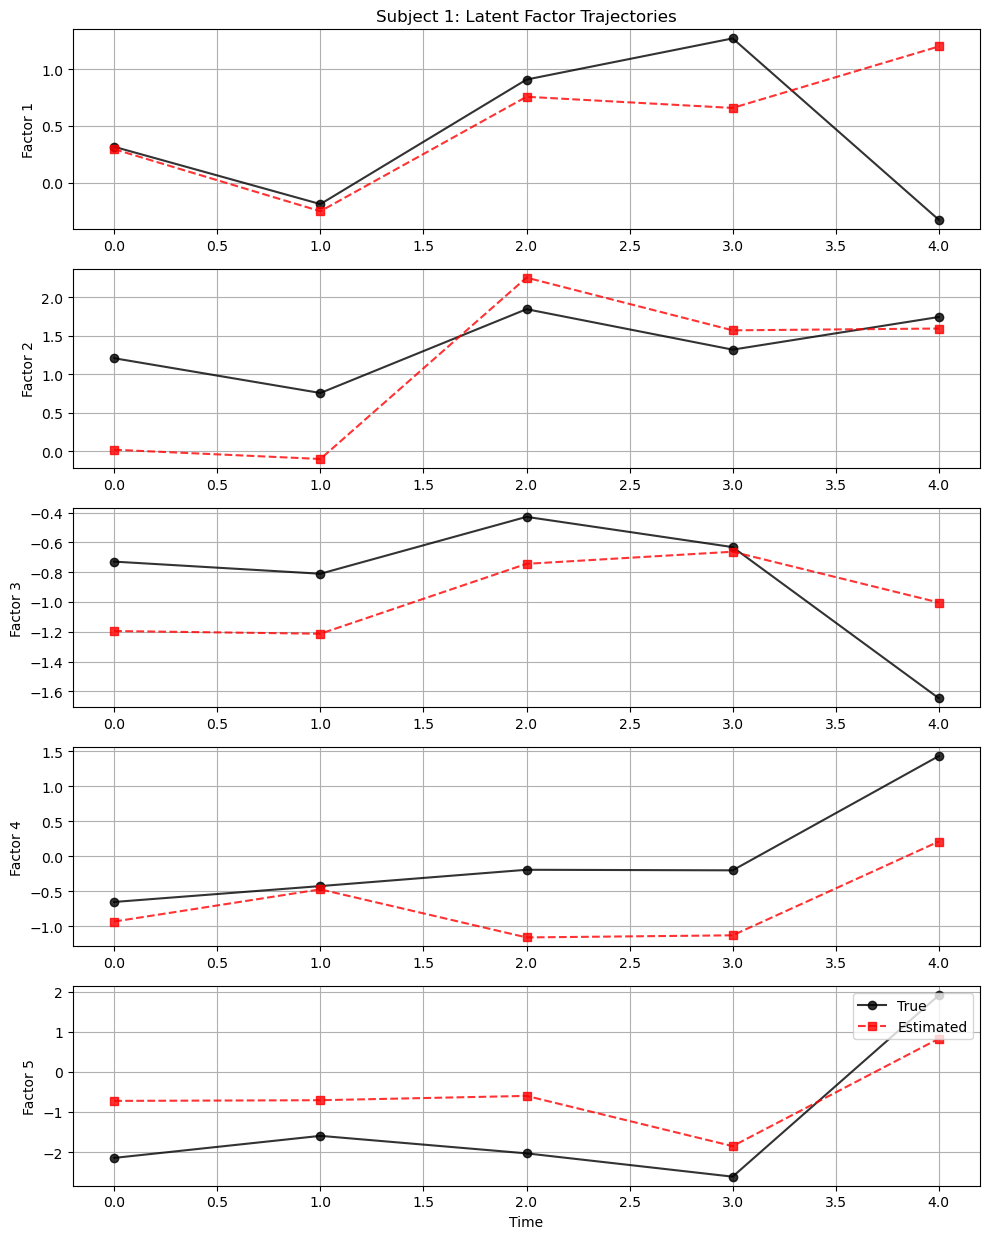

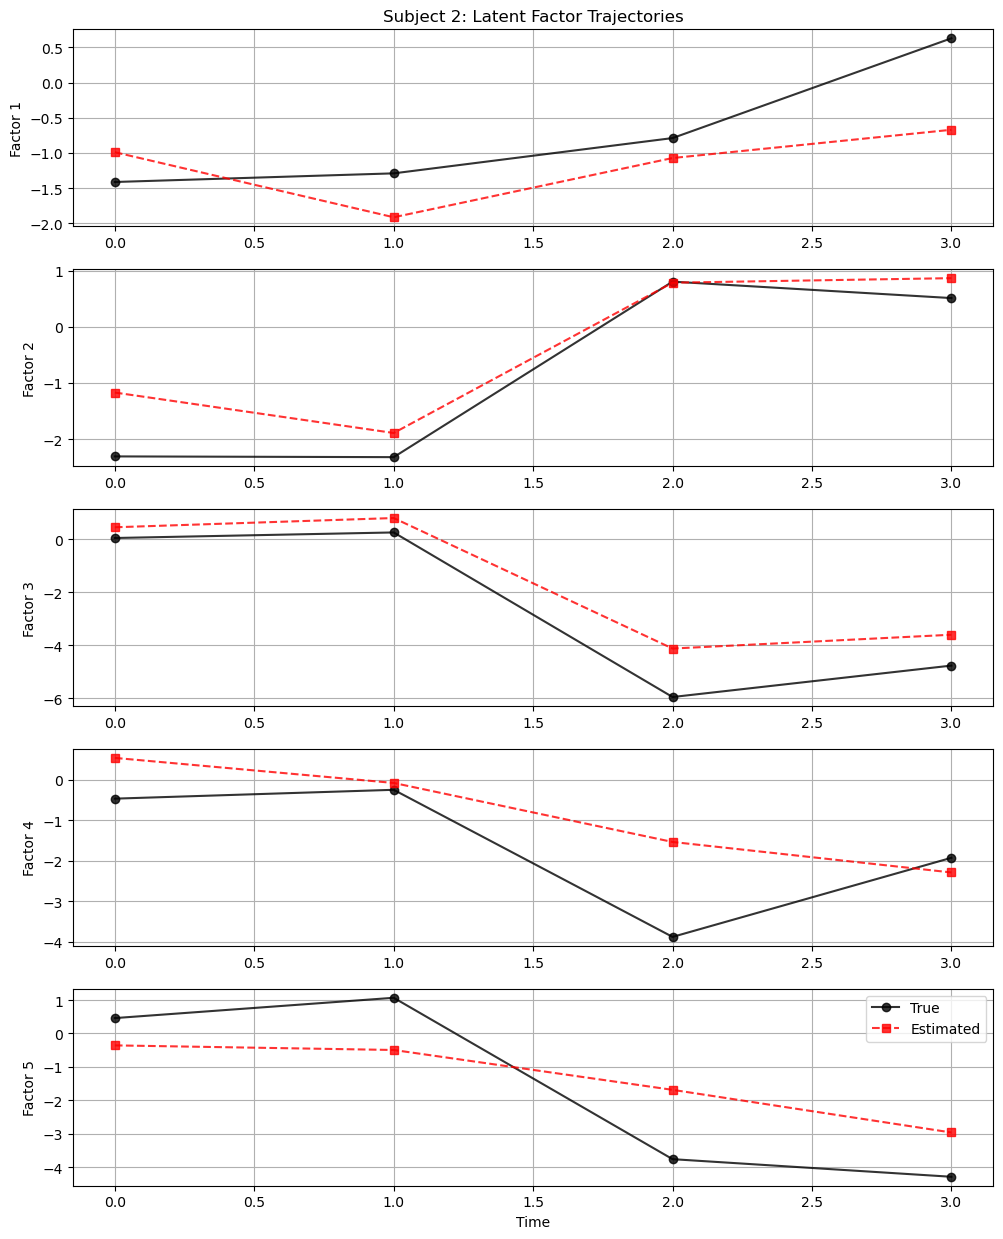

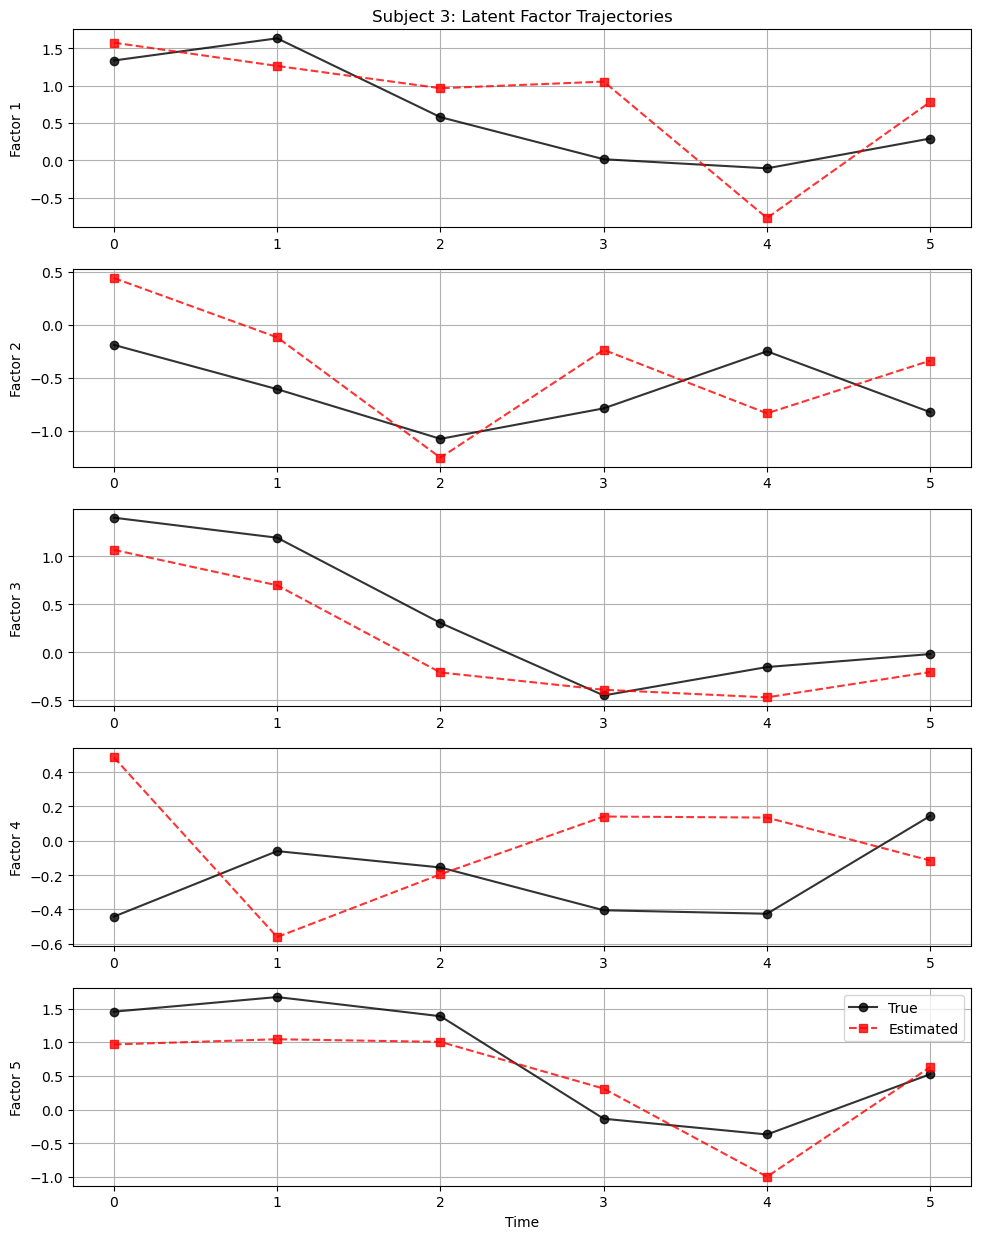

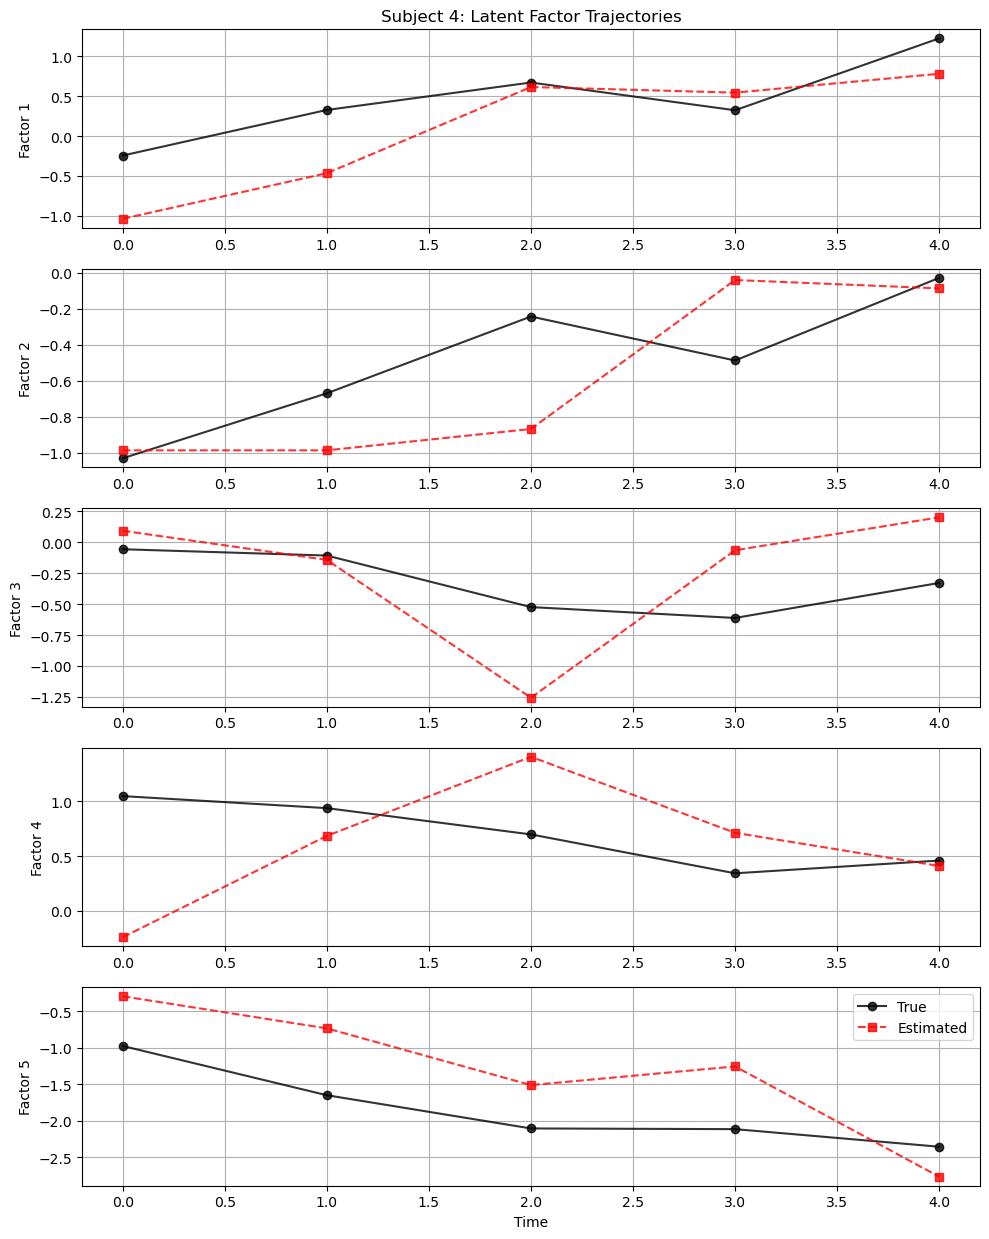

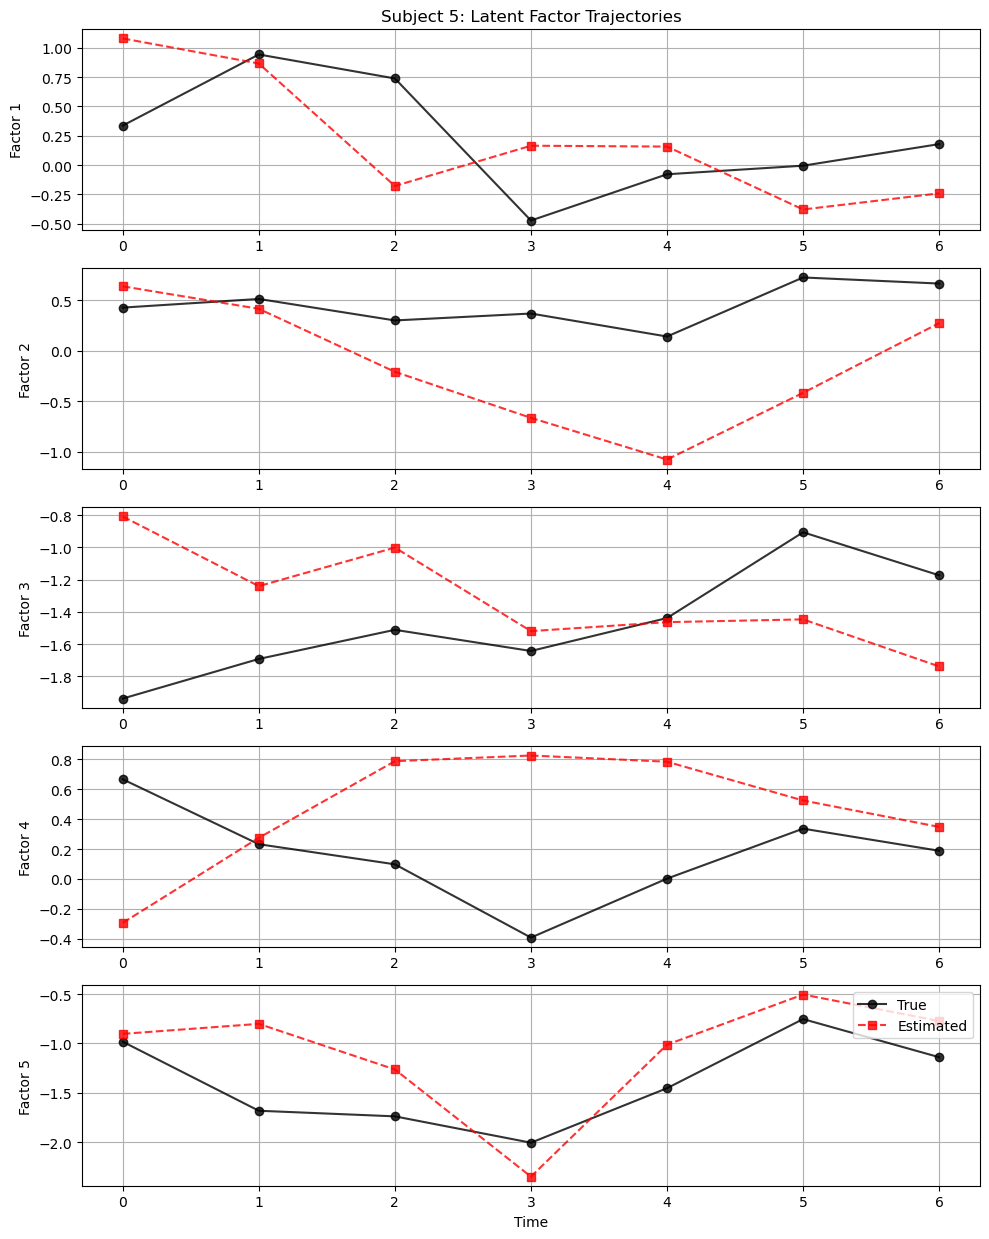

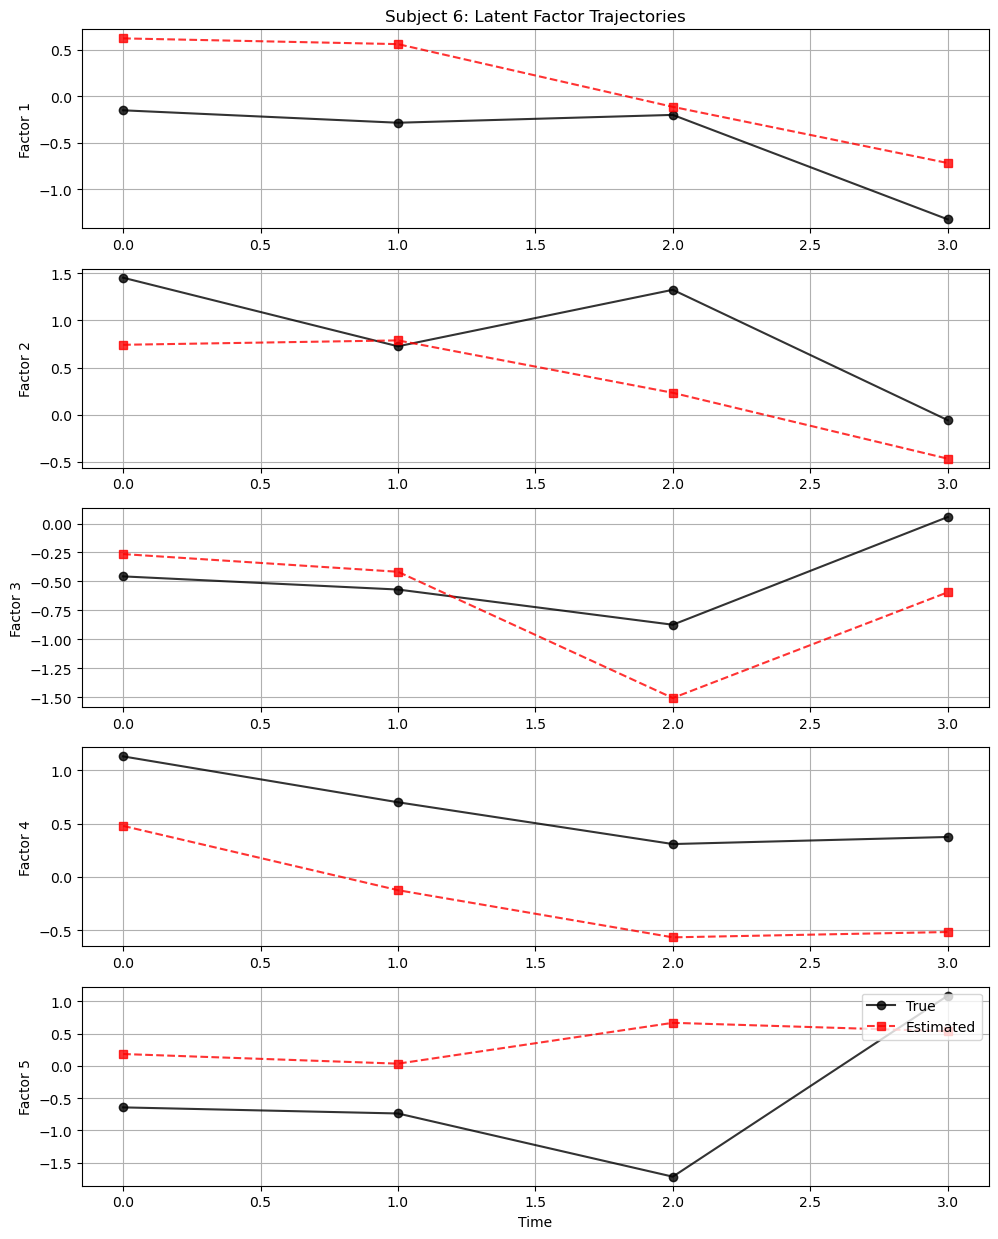

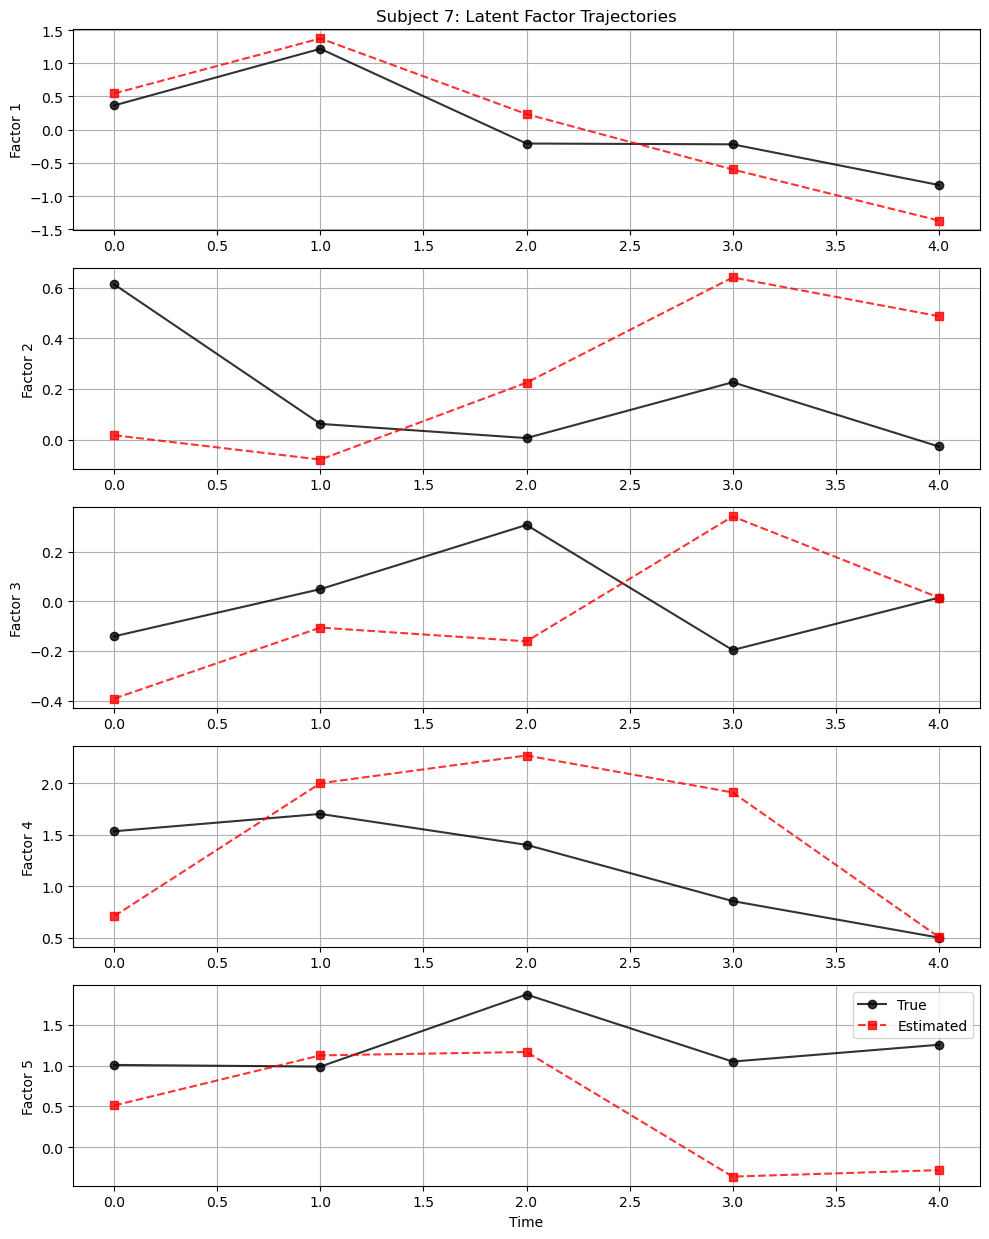

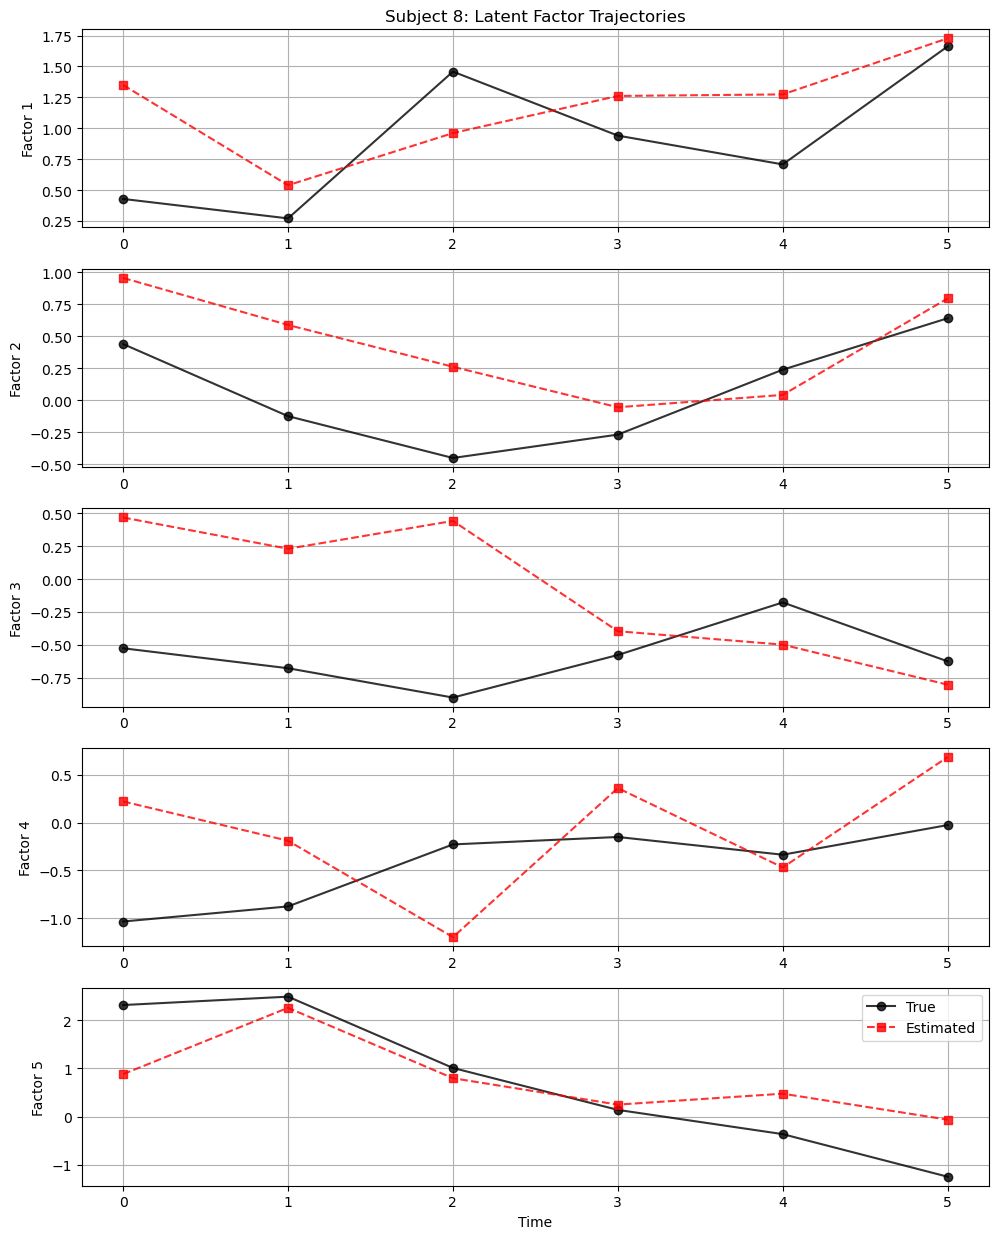

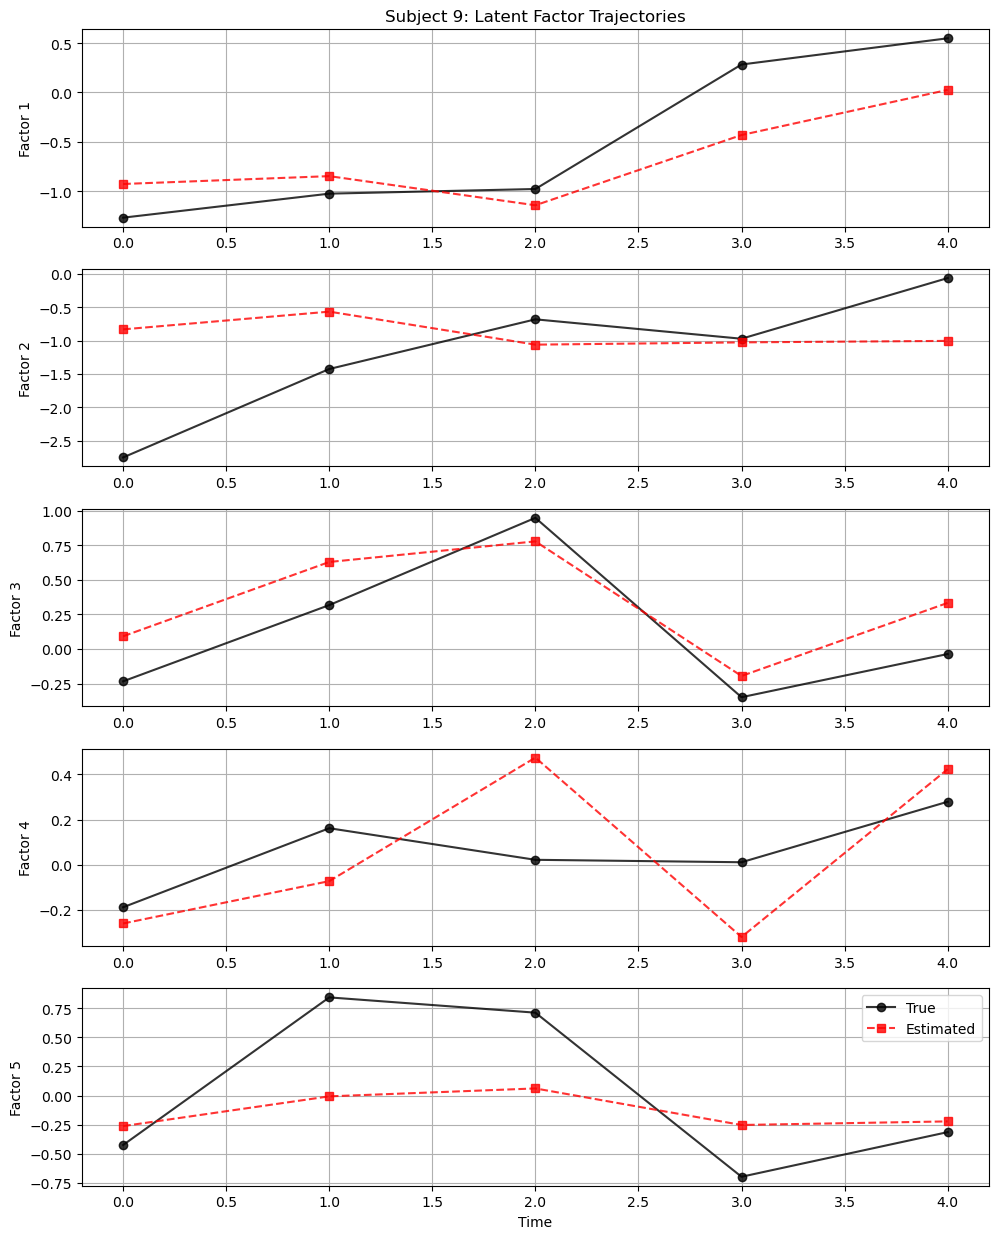

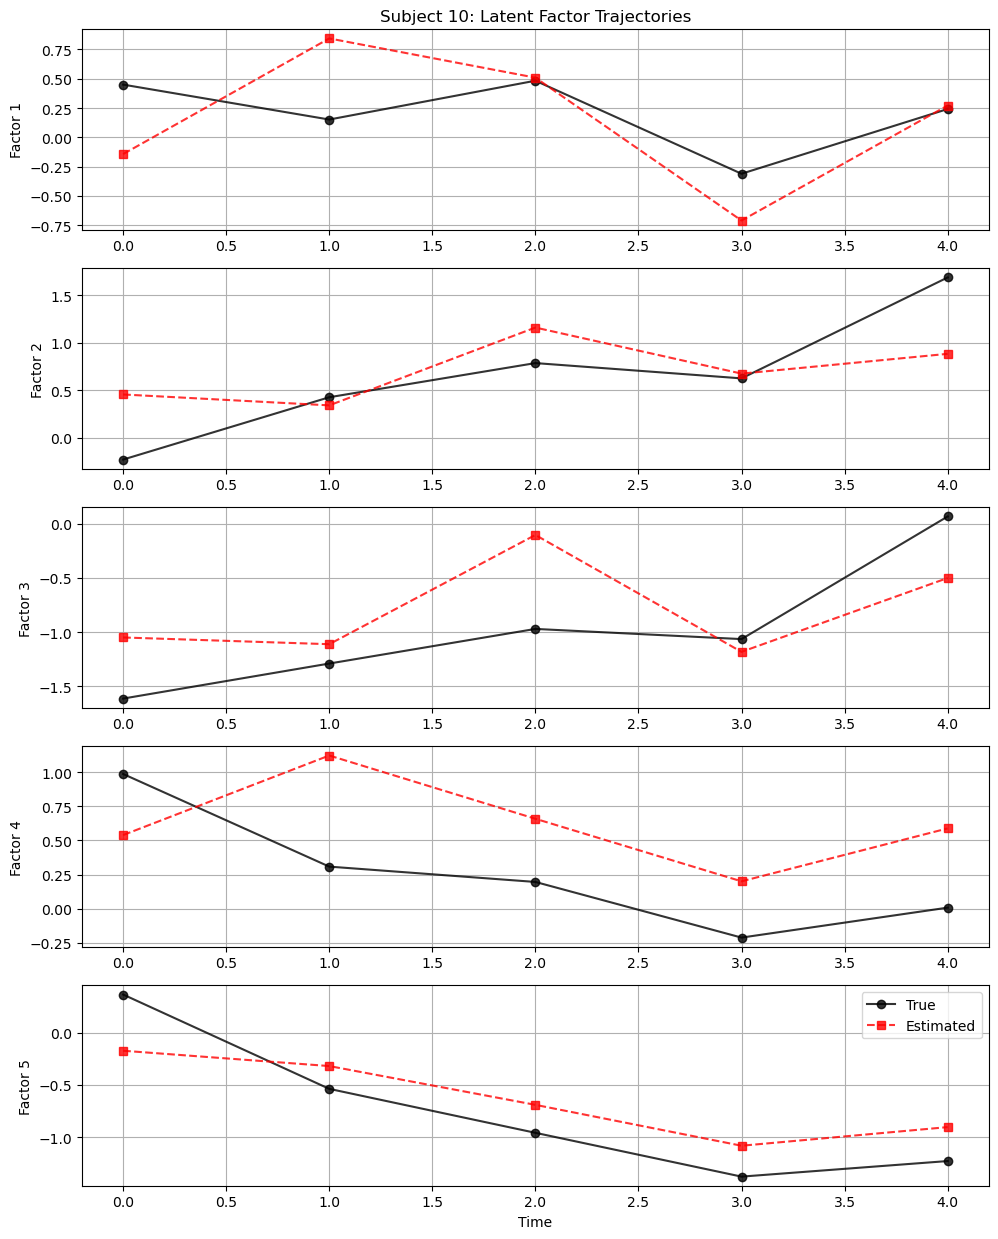

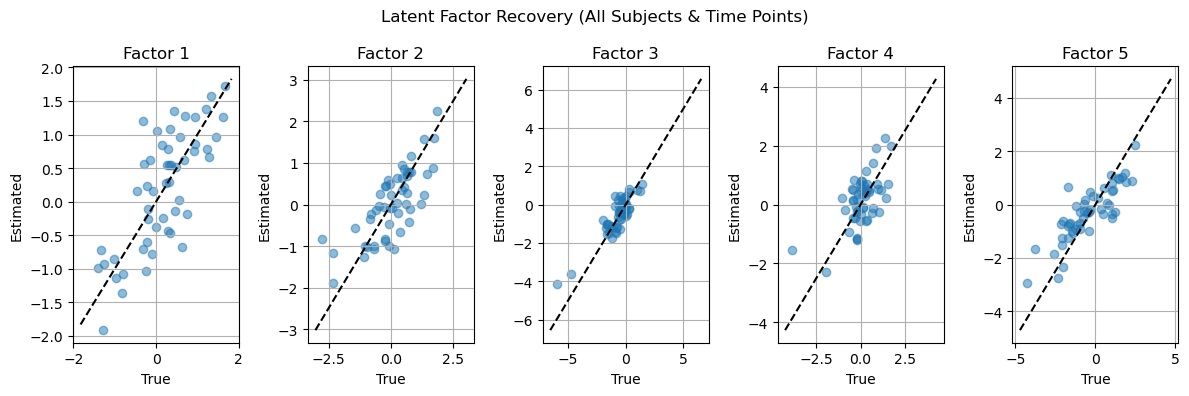


Procrustes-aligned factor recovery: 0.8672688927295141


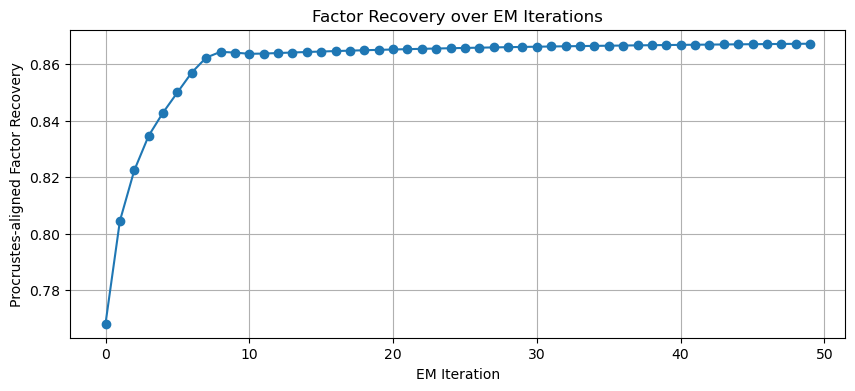

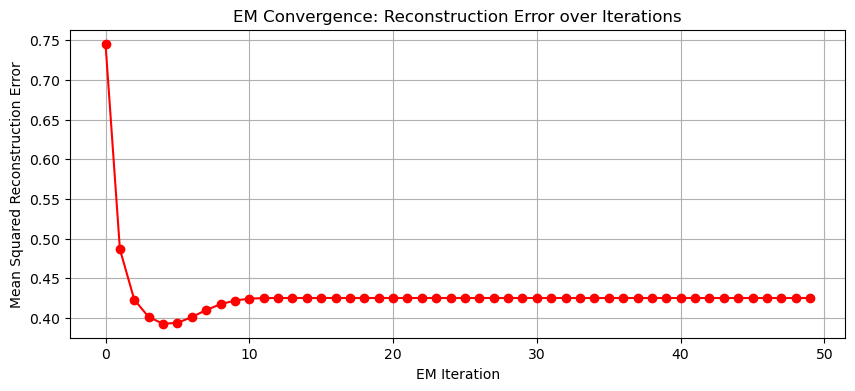

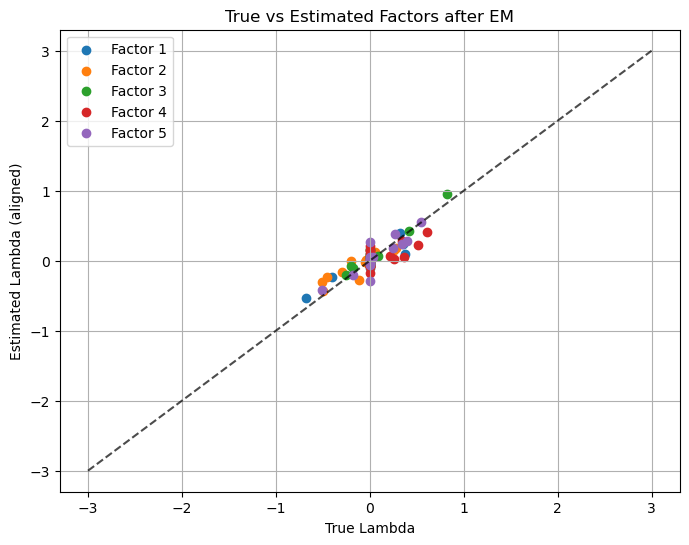

In [7]:
def main_vis():
    n_subjects = 10
    T_list = [5,4,6,5,7,4,5,6,5,5]  # irregular T per subject
    Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
        n_subjects=n_subjects,
        T_list=T_list,
        p=20,
        k=5
    )

    # After EM
    Lambda_est, history_Lambda, _, recon_error_history = run_em_with_history(
        Ys, dts_all, k=5, n_iter=50
    )

    # Re-run E-step with final parameters
    Ezs = []
    for Y, dt in zip(Ys, dts_all):
        Ez, _ = kalman_smoother(Y, Lambda_est, np.eye(Y.shape[1]), 0.05, 1.0, dt)
        Ezs.append(Ez)

    # Align latents
    Ezs_aligned, _ = align_latents(Ezs, Zs, Lambda_est, Lambda_true)

    # Visualize
    plot_latent_trajectories(Zs, Ezs_aligned)
    plot_latent_scatter(Zs, Ezs_aligned)


    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

    plot_em_performance(Lambda_true, history_Lambda, recon_error_history)

if __name__=="__main__":
    main_vis()


In [10]:
def plot_lambda_factor_comparison(Lambda_true, Lambda_est):
    """
    Per-factor scatter plots: true vs estimated Lambda
    after Procrustes alignment.
    """
    k = Lambda_true.shape[1]

    R, _ = orthogonal_procrustes(Lambda_est, Lambda_true)
    Lambda_aligned = Lambda_est @ R

    plt.figure(figsize=(4*k, 4))
    for f in range(k):
        plt.subplot(1, k, f+1)
        plt.scatter(
            Lambda_true[:, f],
            Lambda_aligned[:, f],
            alpha=0.5
        )
        lim = np.max(np.abs(Lambda_true[:, f])) * 1.1
        plt.plot([-lim, lim], [-lim, lim], 'k--')
        plt.xlabel("True")
        plt.ylabel("Estimated")
        plt.title(f"Factor {f+1}")
        plt.grid(True)

    plt.suptitle("Per-factor Lambda recovery (Procrustes aligned)")
    plt.tight_layout()
    plt.show()


In [11]:
def per_factor_recovery(Lambda_true, Lambda_est):
    """
    Returns vector of length k: per-factor correlations
    after Procrustes alignment.
    """
    R, _ = orthogonal_procrustes(Lambda_est, Lambda_true)
    L_aligned = Lambda_est @ R

    k = Lambda_true.shape[1]
    rec = np.zeros(k)
    for f in range(k):
        rec[f] = np.corrcoef(
            Lambda_true[:, f],
            L_aligned[:, f]
        )[0, 1]
    return rec


In [12]:
def plot_per_factor_recovery_across_experiments(per_factor_rec_all):
    """
    per_factor_rec_all: array (n_experiments, k)
    """
    per_factor_rec_all = np.array(per_factor_rec_all)
    k = per_factor_rec_all.shape[1]

    plt.figure(figsize=(1.6*k, 5))
    plt.boxplot(
        [per_factor_rec_all[:, f] for f in range(k)],
        labels=[f"Factor {f+1}" for f in range(k)]
    )
    plt.ylabel("Correlation (true vs estimated)")
    plt.title("Per-factor Lambda recovery across experiments")
    plt.grid(axis='y')
    plt.show()


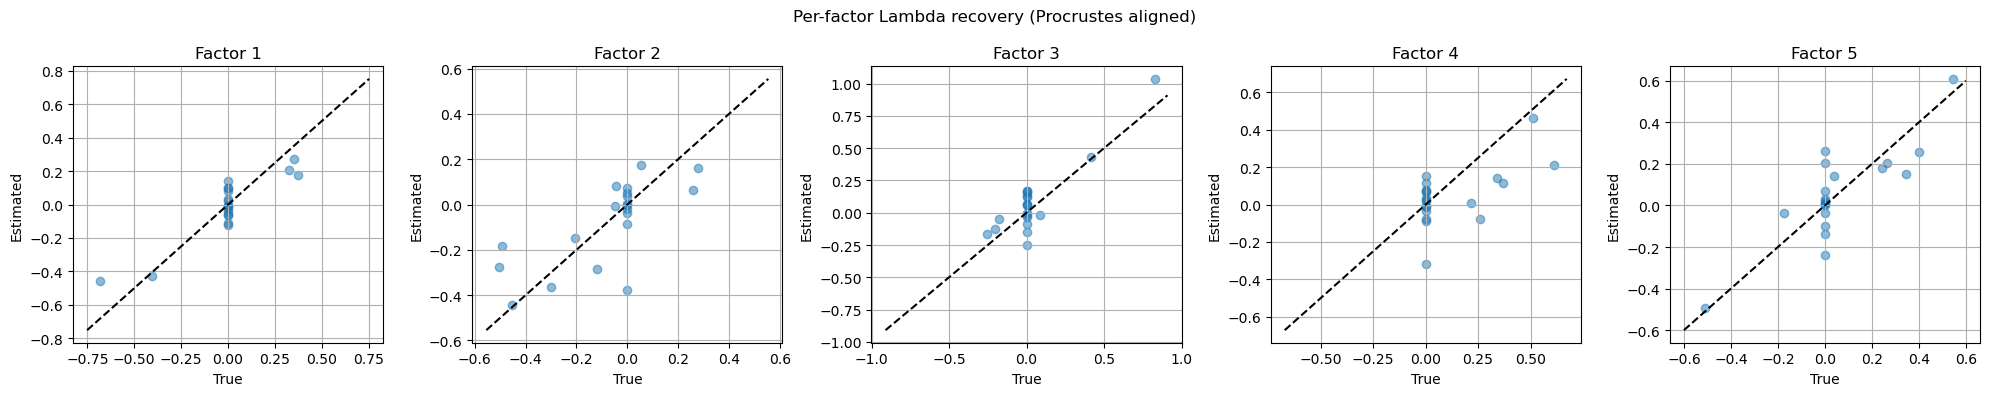

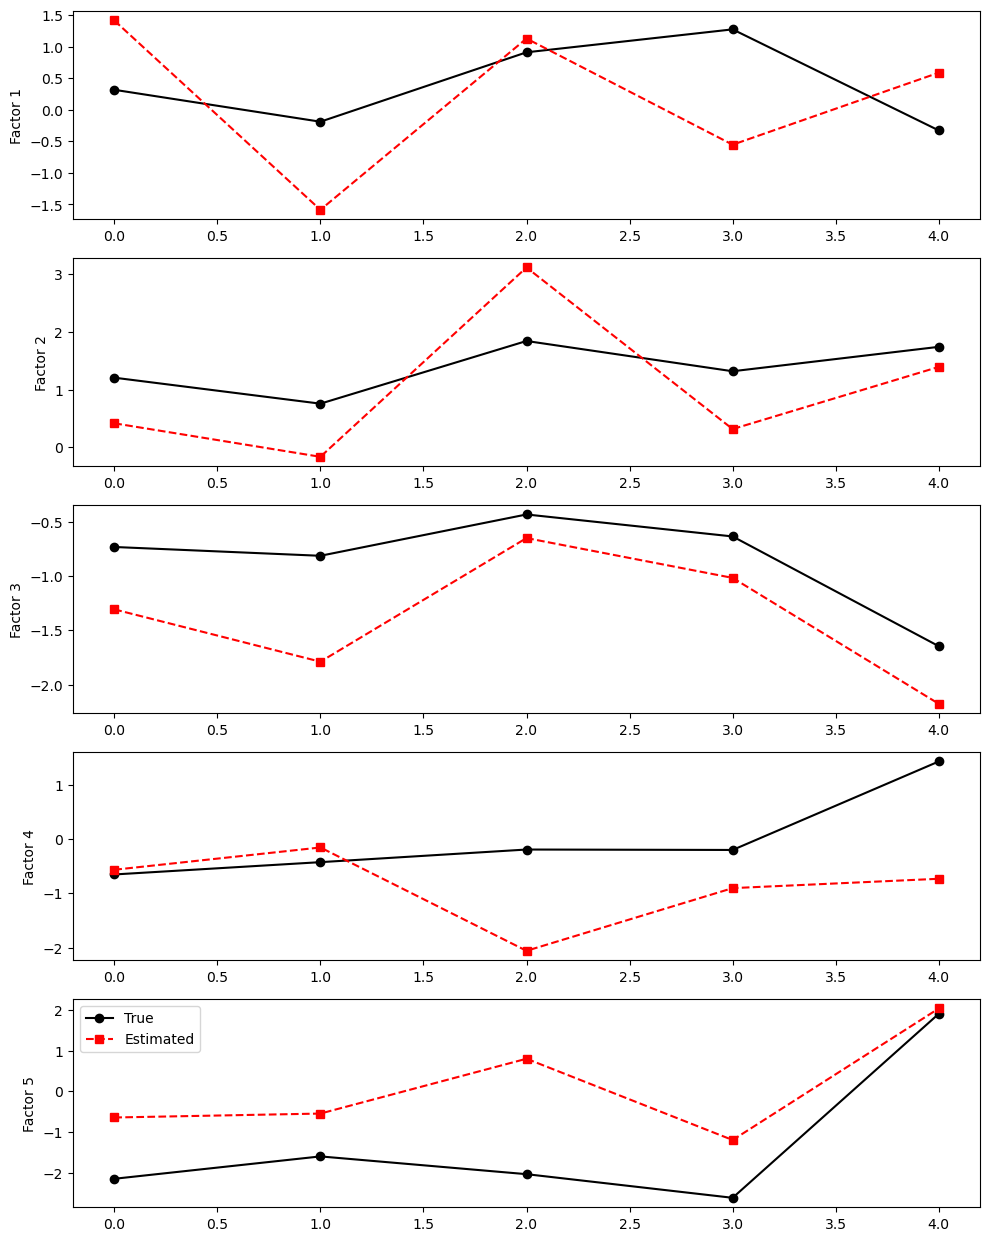

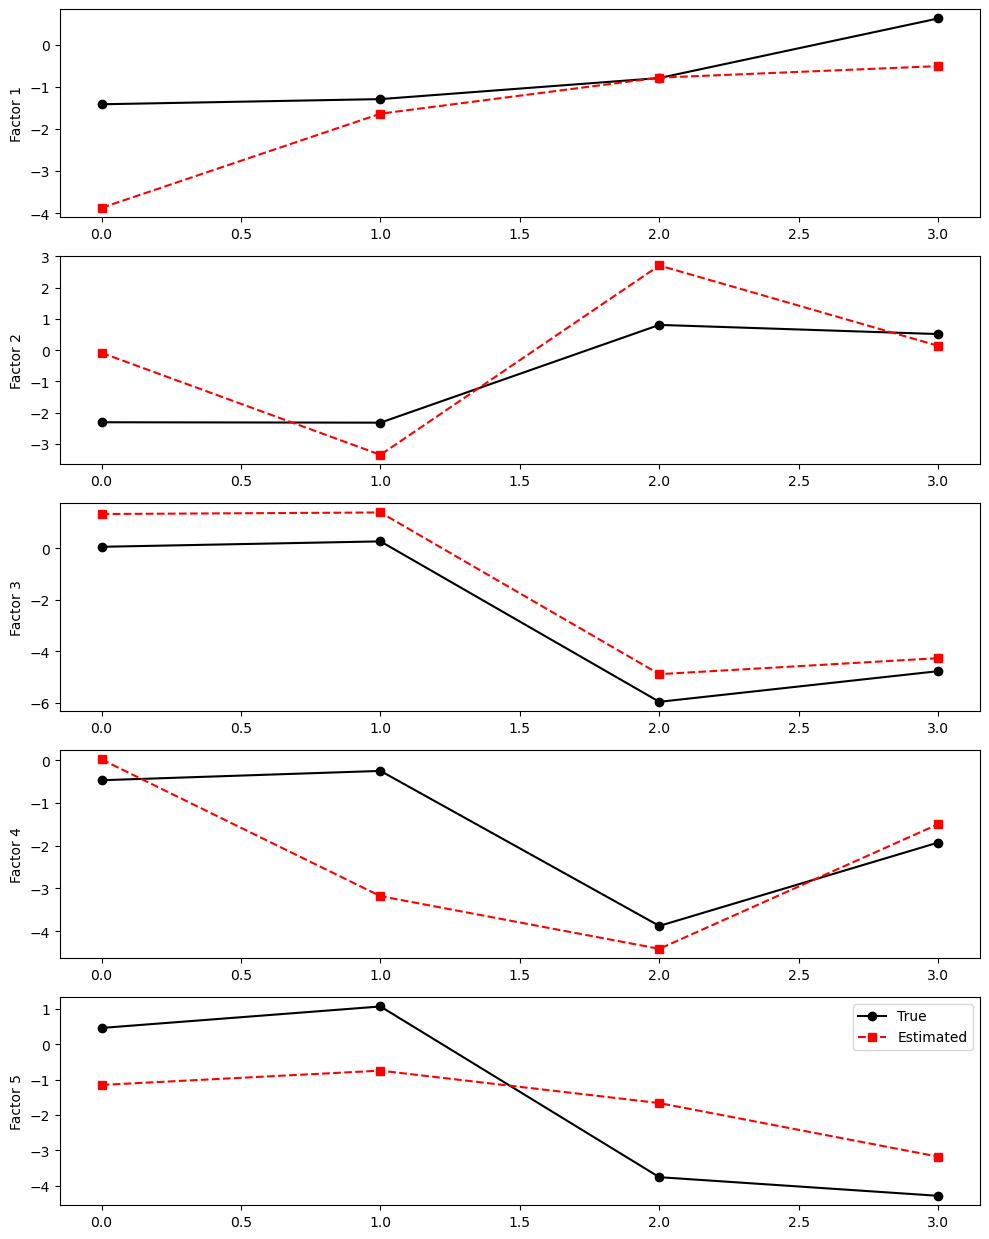

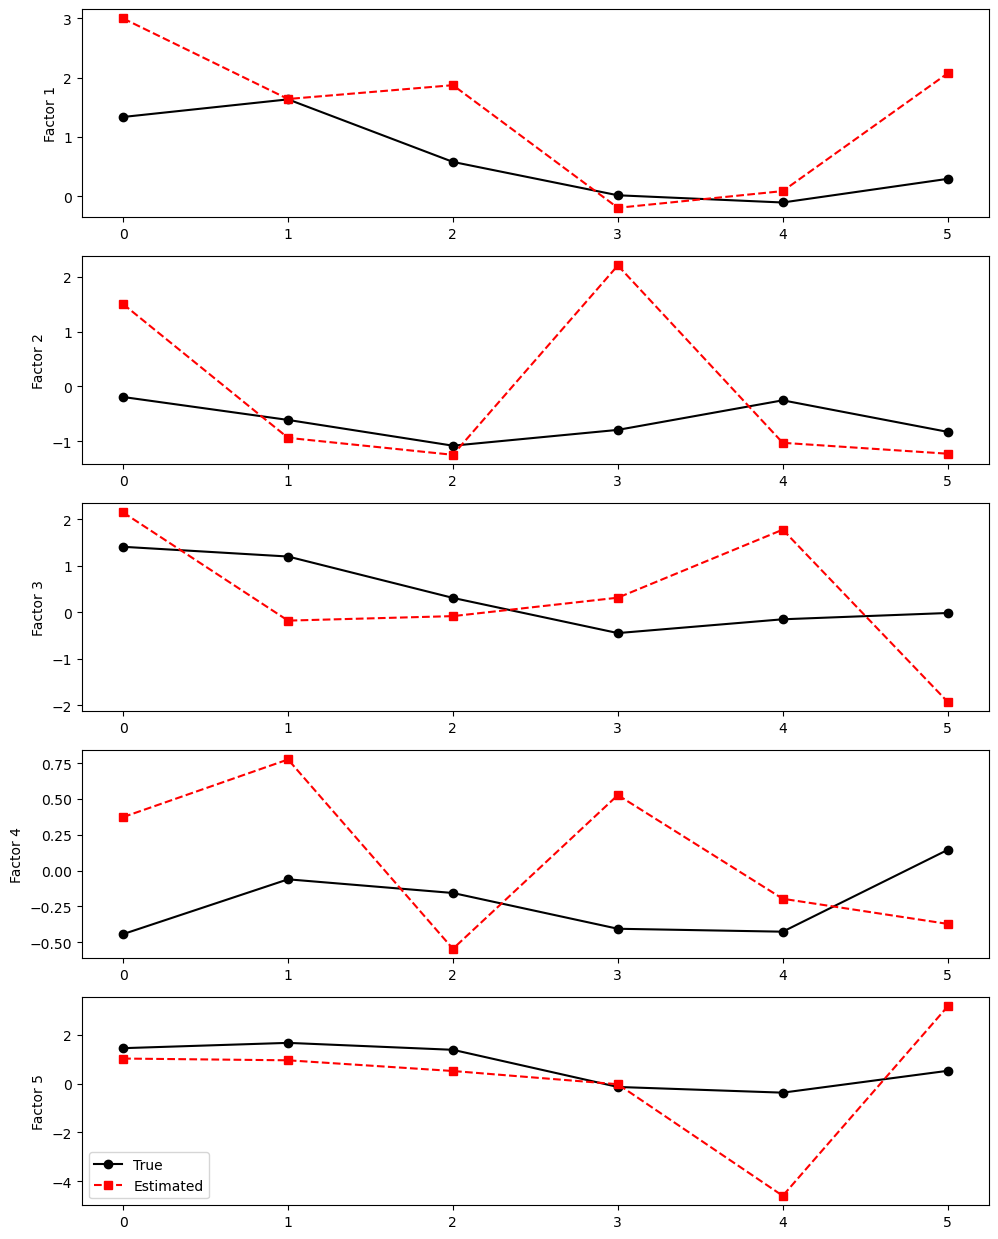

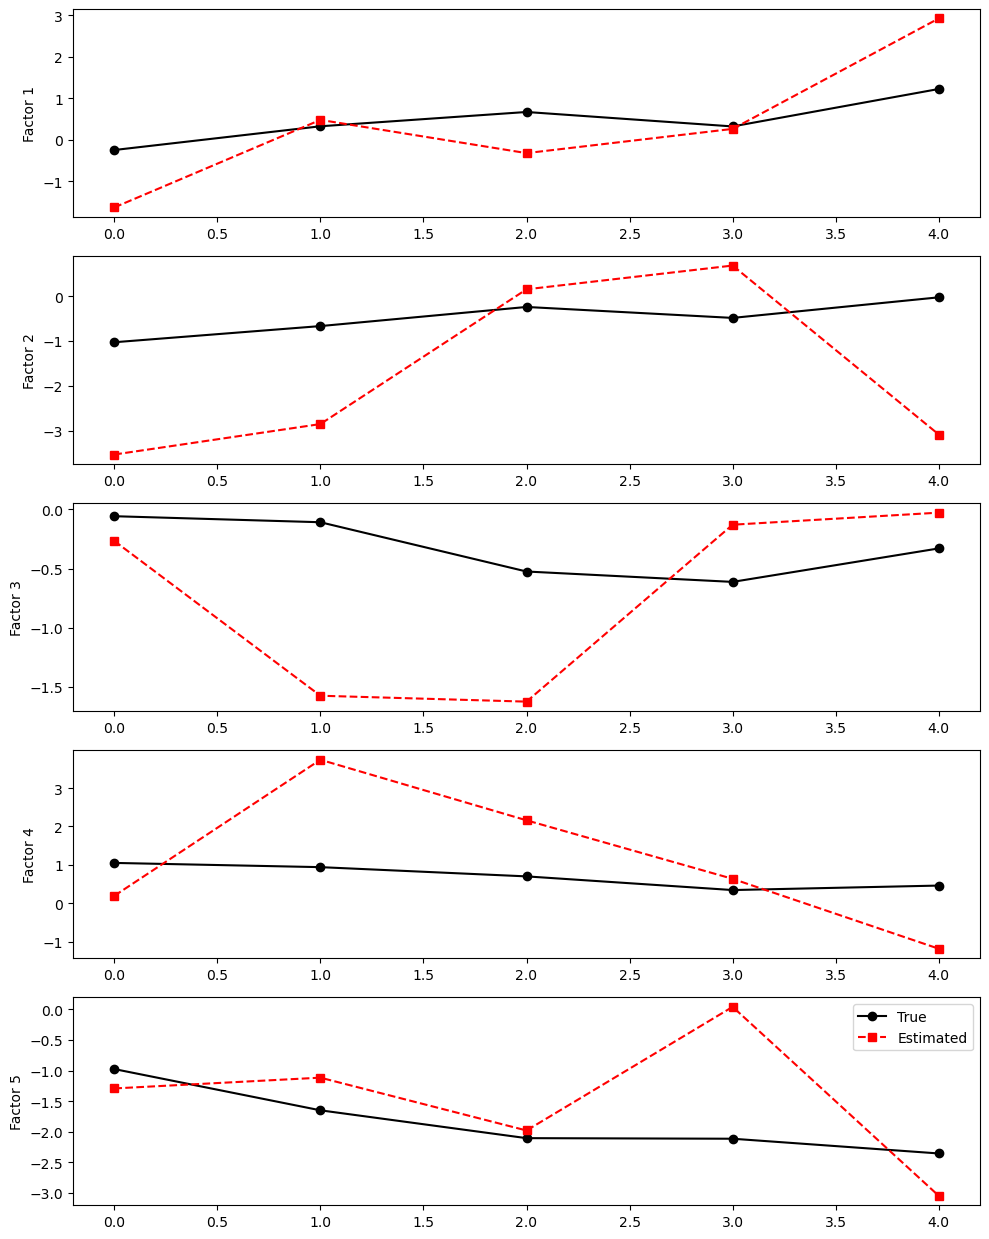

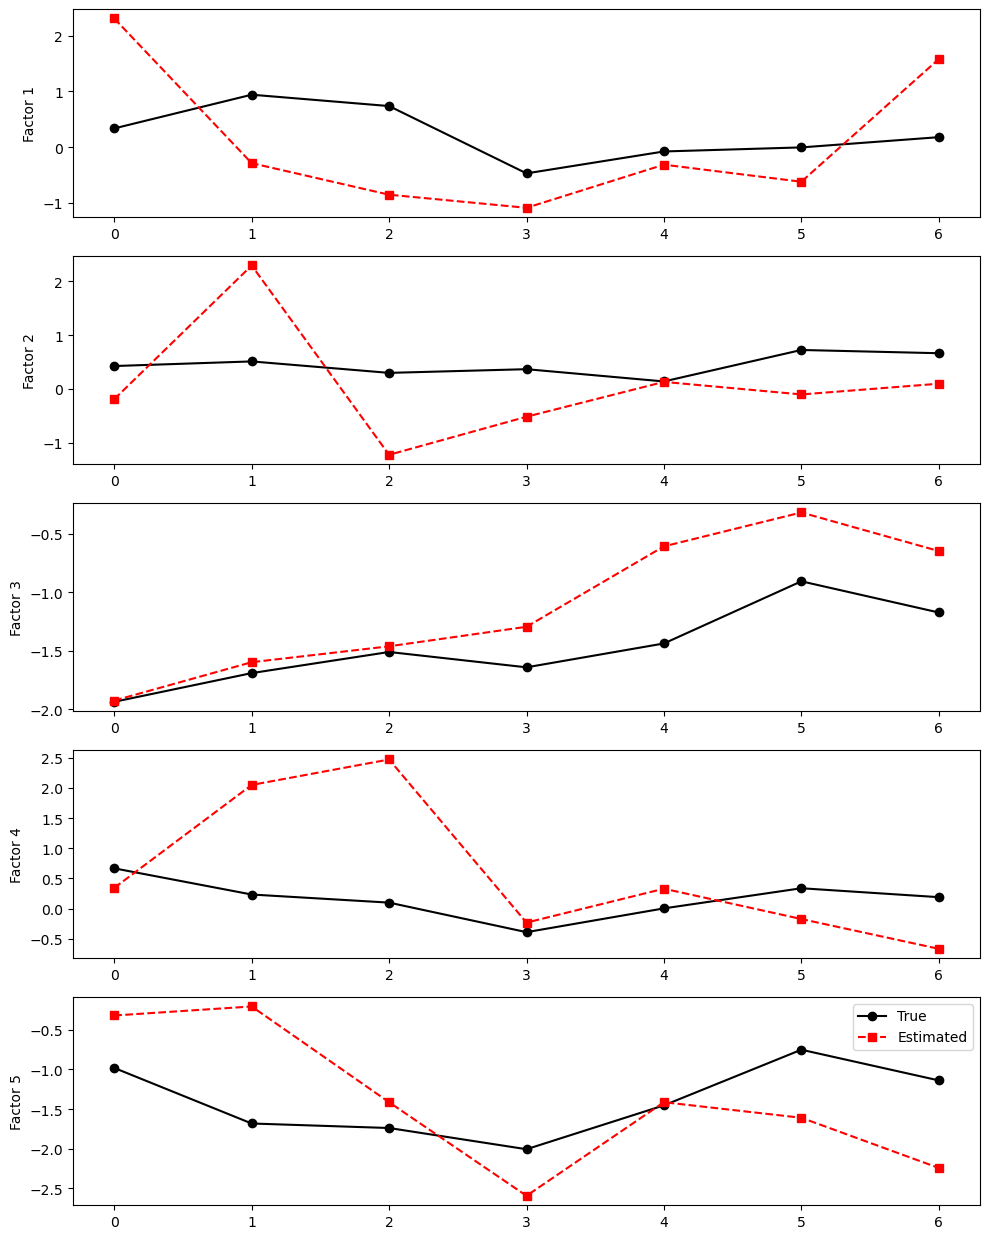

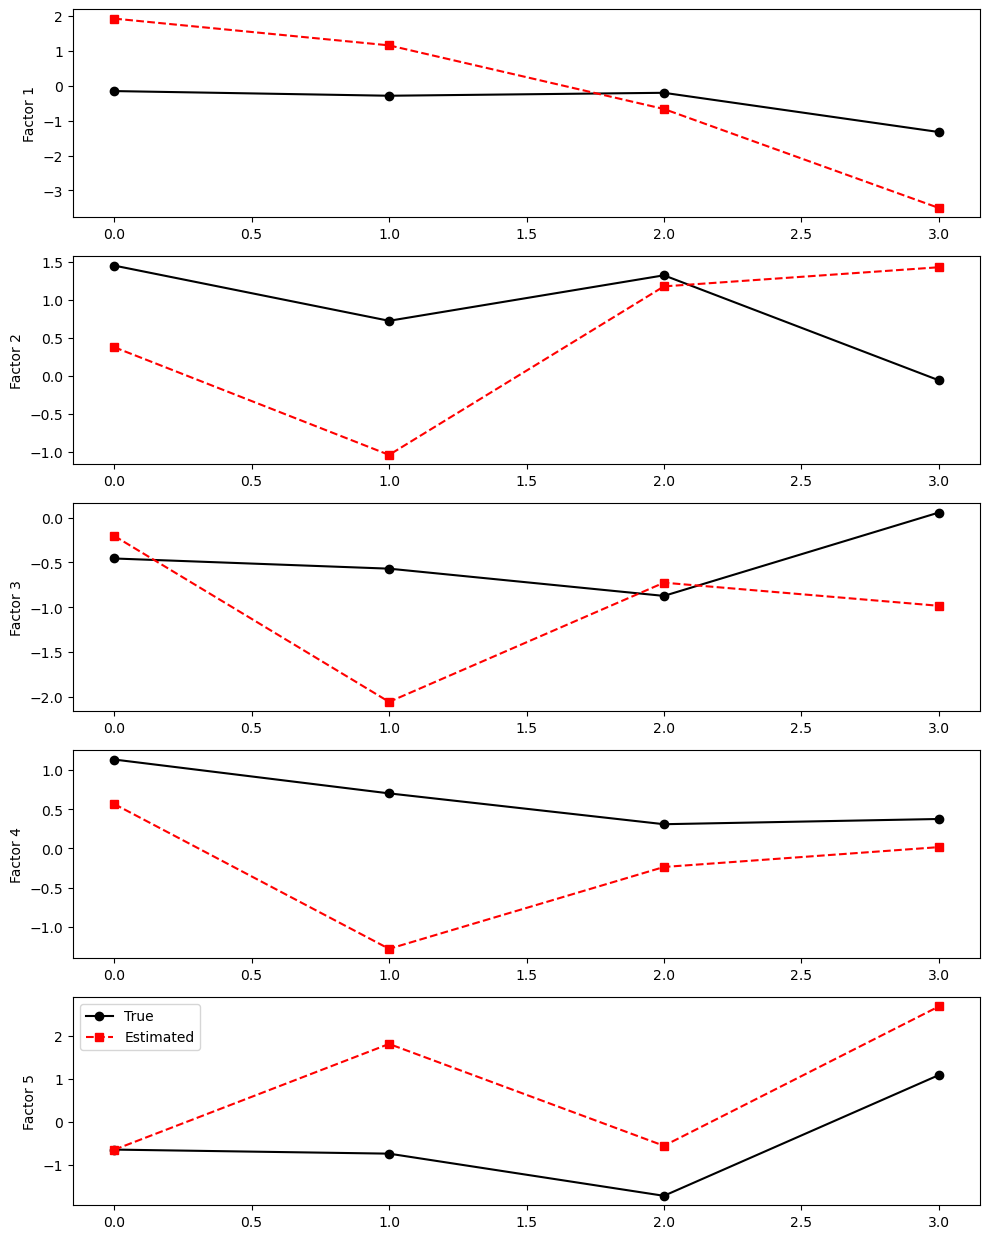

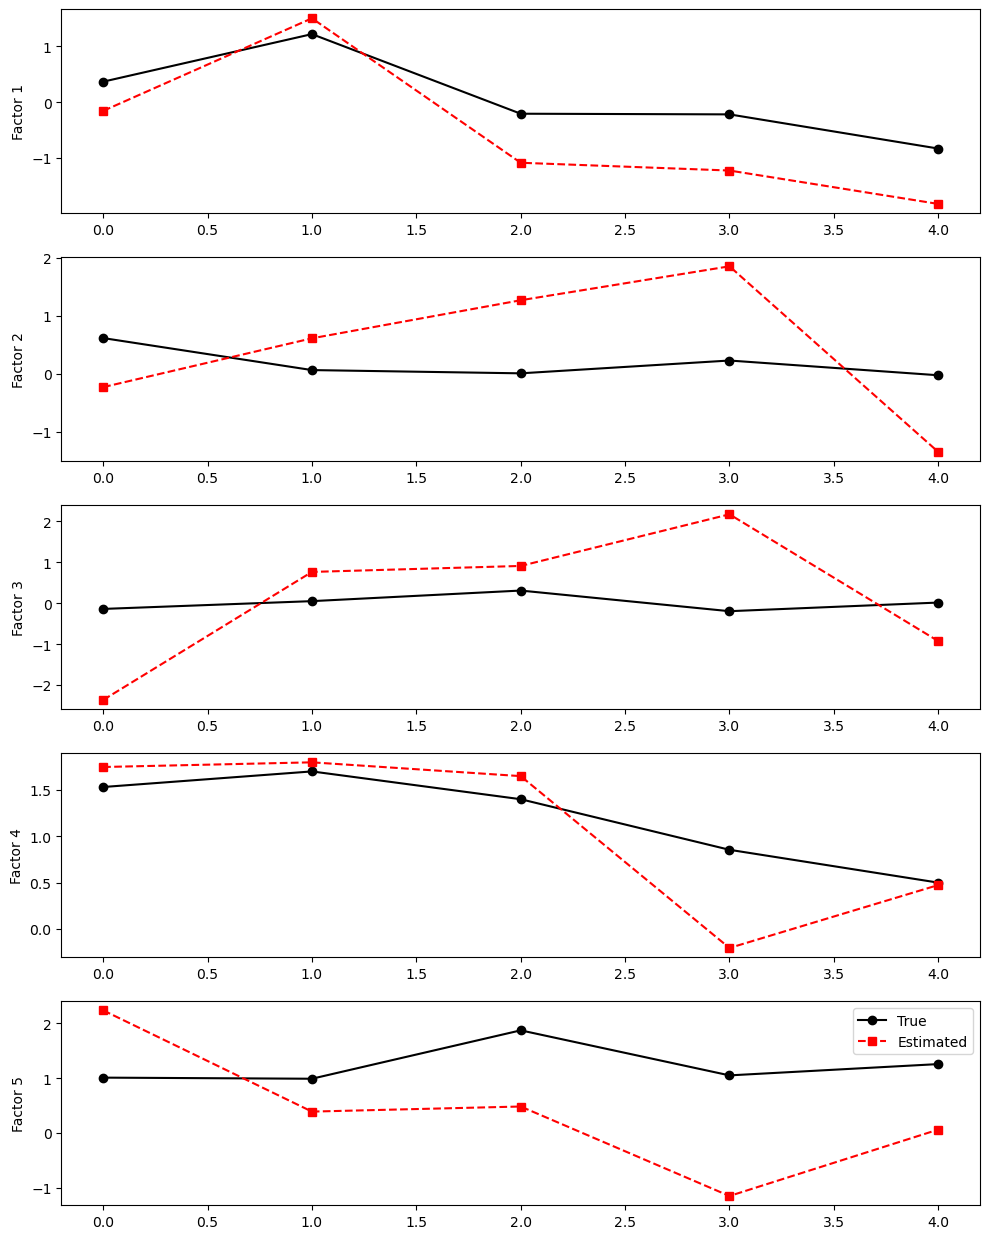

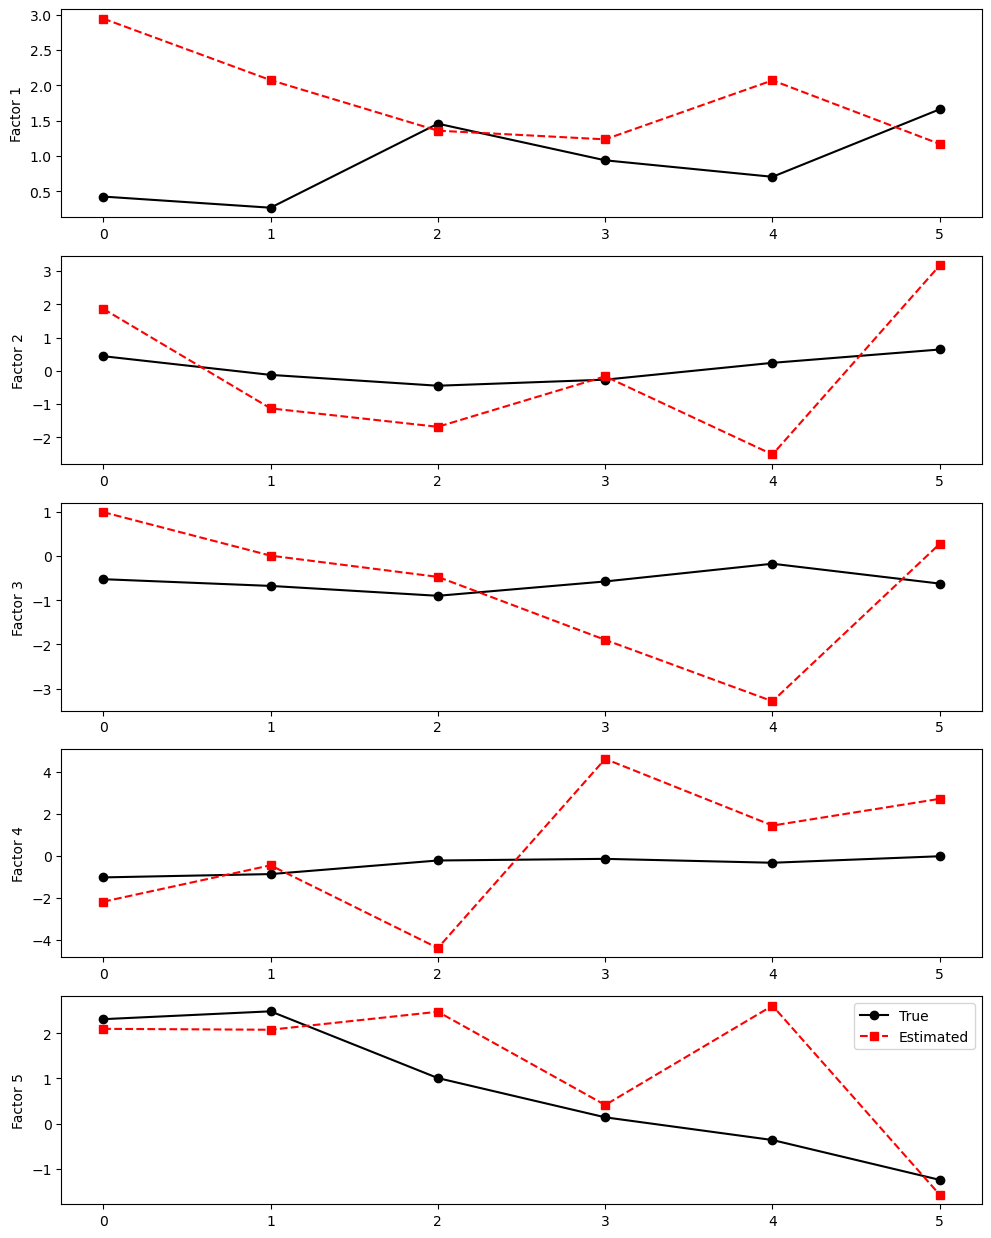

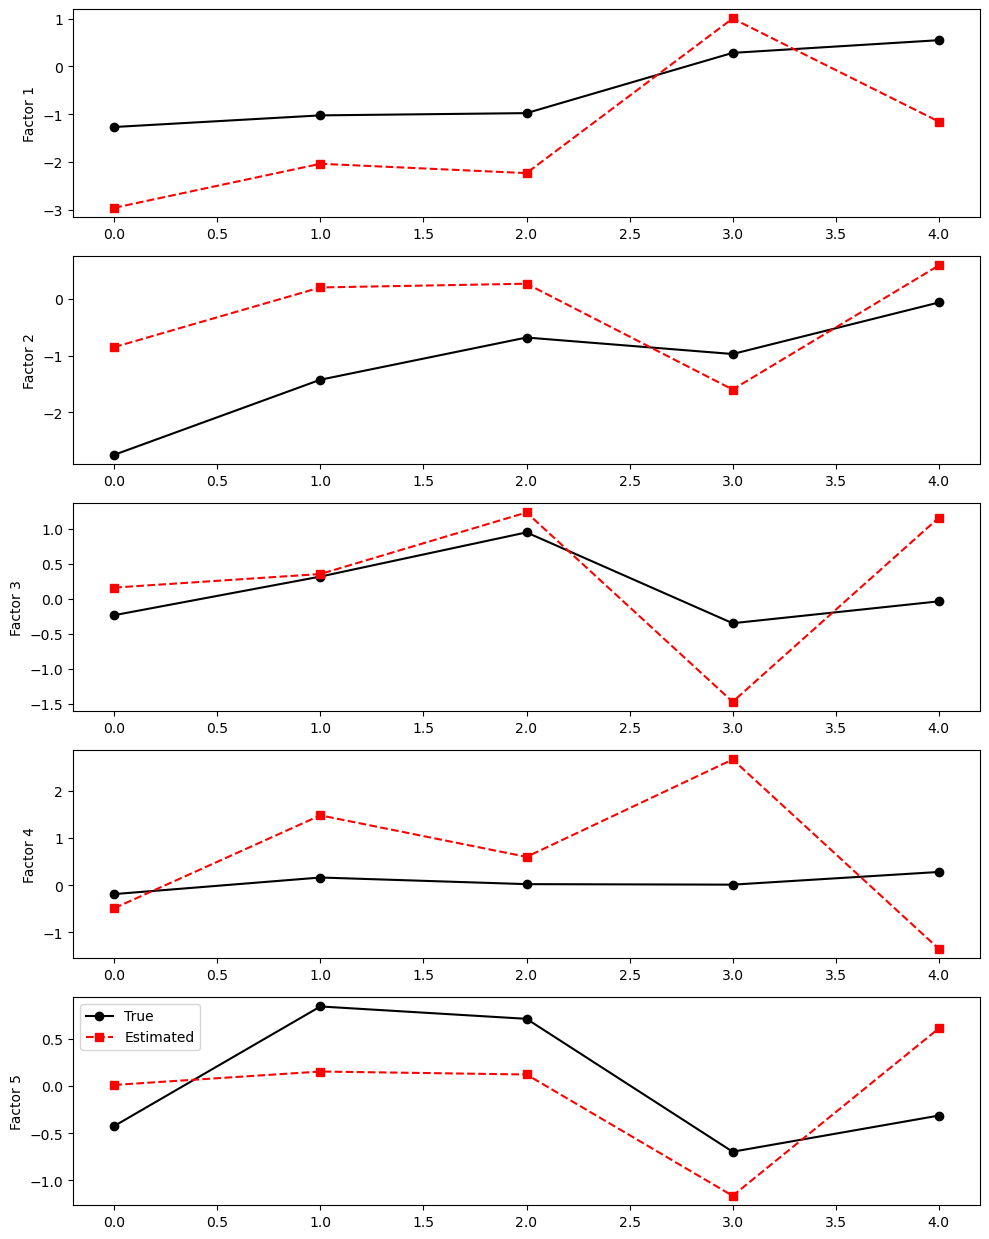

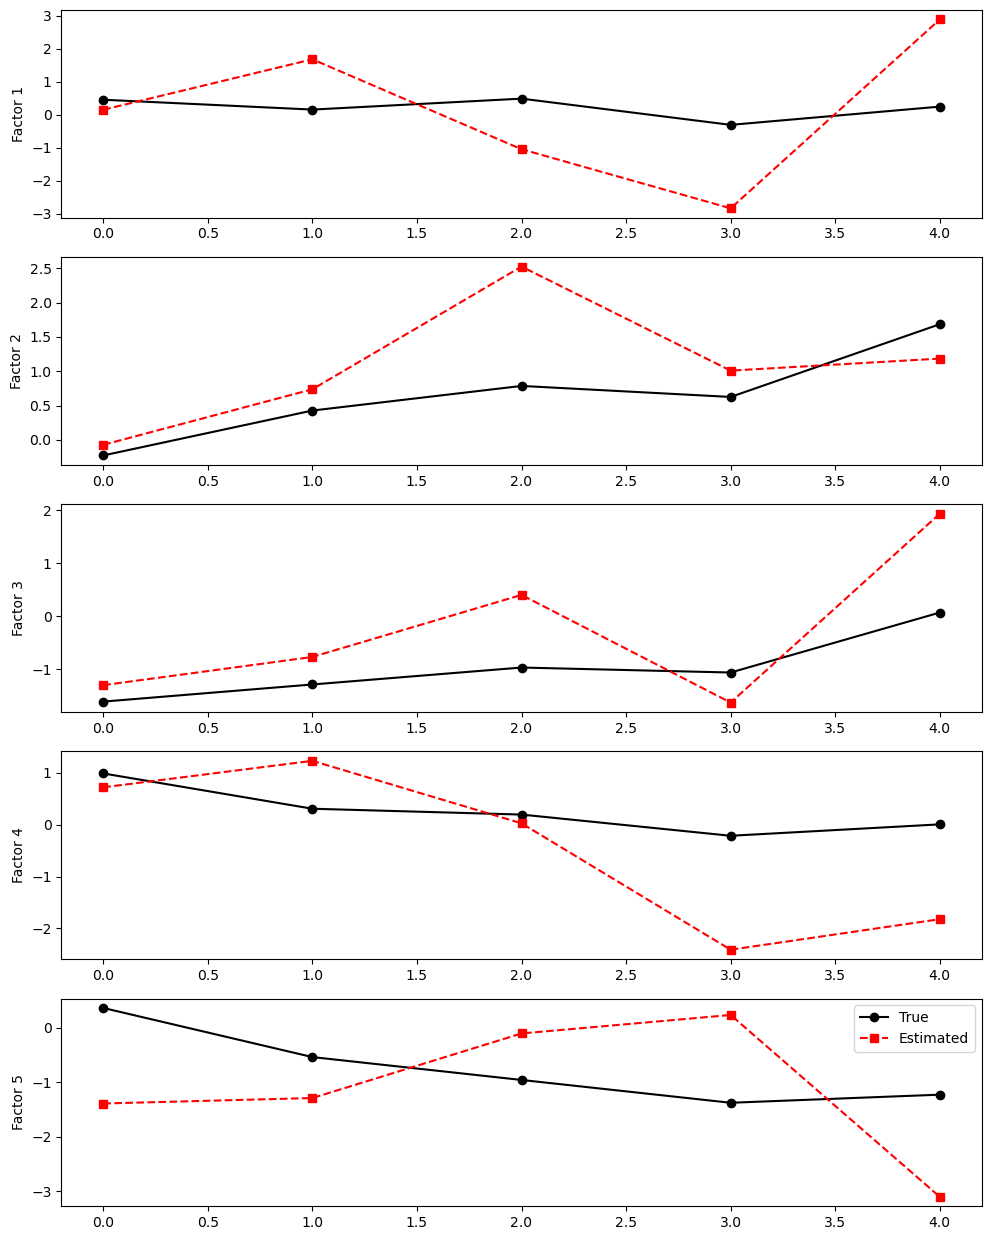

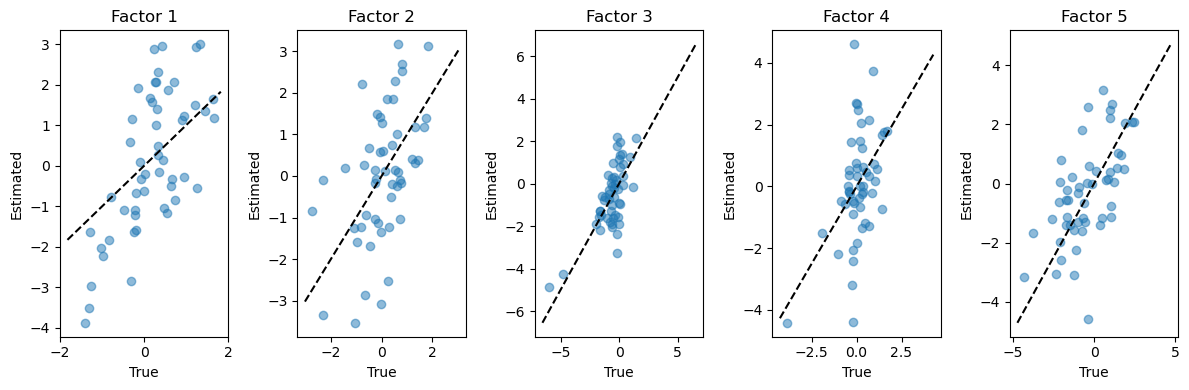

/tmp/ipykernel_2414630/433983688.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


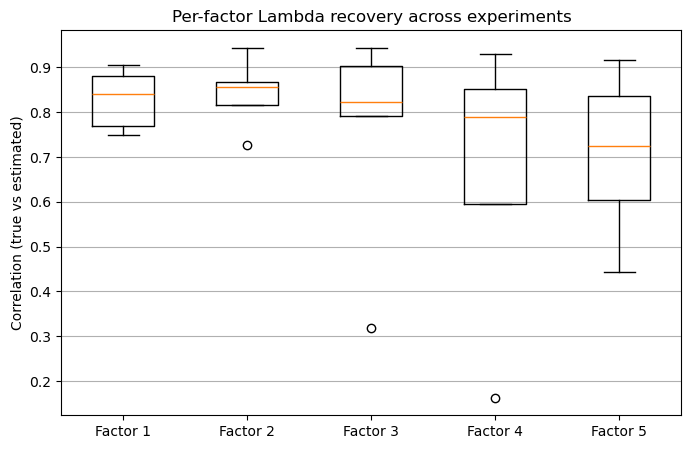

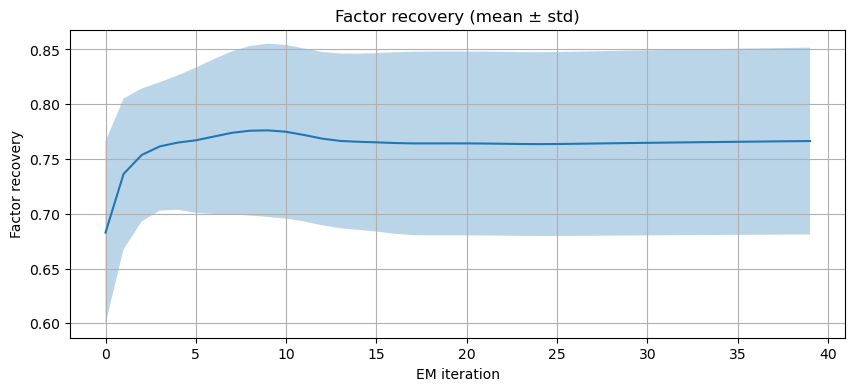

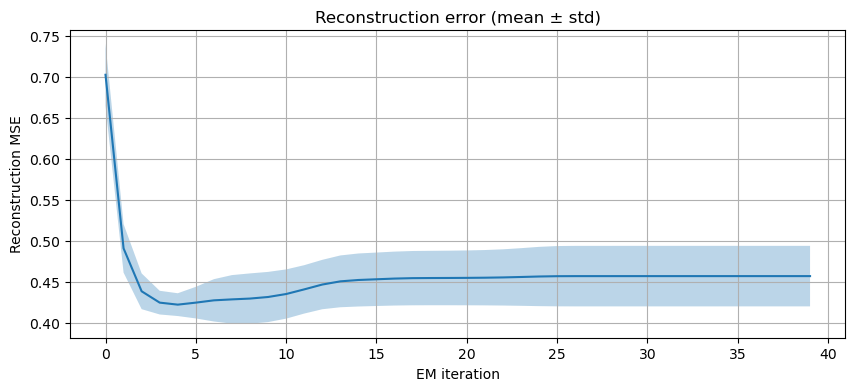

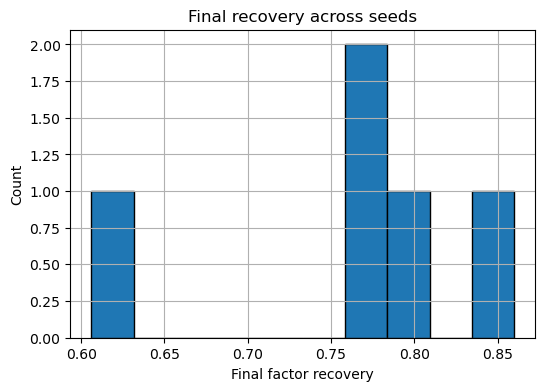

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ======================================================
# Simulation
# ======================================================
def simulate_ou_dfa(
    n_subjects=10,
    T_list=None,
    p=20,
    k=5,
    rho_mean=0.05,
    rho_sd=0.03,
    Q_scale=0.3,
    Psi_scale=0.5,
    sparsity=0.7,
    shock_prob=0.05,
    shock_scale=3.0,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    if T_list is None:
        T_list = [10] * n_subjects

    Lambda_true = rng.normal(0, 1, size=(p, k))
    mask = rng.uniform(size=(p, k)) > sparsity
    Lambda_true *= mask
    if k > 1:
        Lambda_true[:, 1] += 0.8 * Lambda_true[:, 0]
    Lambda_true /= np.linalg.norm(Lambda_true, axis=0, keepdims=True)

    rho = np.abs(rng.normal(rho_mean, rho_sd, size=k))
    R = rng.normal(size=(k, k))
    Q = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 10.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(0, 1, size=k)

        for t in range(1, T):
            A = np.diag(np.exp(-rho * dt[t - 1]))
            z[t] = A @ z[t - 1] + rng.multivariate_normal(np.zeros(k), Q)
            if rng.uniform() < shock_prob:
                z[t] += rng.normal(0, shock_scale, size=k)

        Psi_diag = Psi_scale * rng.lognormal(0.0, 0.5, size=p)
        y = z @ Lambda_true.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda_true, dts_all

# ======================================================
# Kalman smoother
# ======================================================
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))
    eps = 1e-5

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            m = A @ m
            P = A @ P @ A.T + Q * np.eye(k)

        S = Lambda @ P @ Lambda.T + Psi + eps * np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)

        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz

# ======================================================
# EM updates
# ======================================================
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    p = Ys[0].shape[1]
    k = Ez_all[0].shape[1]

    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        for t in range(Y.shape[0]):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    ridge = np.eye(k) / (tau * lam**2 + eps)
    Lambda = np.zeros((p, k))
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda

def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ez_all):
        for t in range(Y.shape[0]):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1
    return np.diag(num / den + eps)

# ======================================================
# EM with history
# ======================================================
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)

    rho = 0.05
    Q = 1.0

    history_Lambda = []
    recon_error = []

    for _ in range(n_iter):
        Ezs, Ezzs = [], []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        Lambda = update_Lambda(Ezs, Ezzs, Ys)
        Psi = update_Psi(Ys, Ezs, Lambda)

        history_Lambda.append(Lambda.copy())

        mse = sum(np.sum((Y - Ez @ Lambda.T)**2) for Y, Ez in zip(Ys, Ezs))
        recon_error.append(mse / sum(Y.size for Y in Ys))

    return Lambda, history_Lambda, recon_error, Ezs

# ======================================================
# Metrics + alignment
# ======================================================
def factor_recovery(L_true, L_est):
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    return np.corrcoef(L_true.ravel(), L_aligned.ravel())[0, 1]

def align_latents(Ezs, Lambda_est, Lambda_true):
    R, _ = orthogonal_procrustes(Lambda_est, Lambda_true)
    return [Ez @ R for Ez in Ezs]

# ======================================================
# Visualization: single experiment
# ======================================================
def plot_latent_trajectories(Zs, Ezs):
    k = Zs[0].shape[1]
    for i in range(len(Zs)):
        plt.figure(figsize=(10, 2.5*k))
        for f in range(k):
            plt.subplot(k, 1, f+1)
            plt.plot(Zs[i][:,f], 'k-o', label='True')
            plt.plot(Ezs[i][:,f], 'r--s', label='Estimated')
            plt.ylabel(f"Factor {f+1}")
        plt.legend()
        plt.tight_layout()
        plt.show()

def plot_latent_scatter(Zs, Ezs):
    Z = np.vstack(Zs)
    E = np.vstack(Ezs)
    k = Z.shape[1]
    plt.figure(figsize=(12,4))
    for f in range(k):
        plt.subplot(1,k,f+1)
        plt.scatter(Z[:,f], E[:,f], alpha=0.5)
        lim = np.max(np.abs(Z[:,f])) * 1.1
        plt.plot([-lim, lim], [-lim, lim], 'k--')
        plt.title(f"Factor {f+1}")
        plt.xlabel("True")
        plt.ylabel("Estimated")
    plt.tight_layout()
    plt.show()

# ======================================================
# Visualization: multiple experiments
# ======================================================
def plot_multi_experiment_curves(recovery_hist, recon_hist):
    recovery_hist = np.array(recovery_hist)
    recon_hist = np.array(recon_hist)

    mean_rec = recovery_hist.mean(axis=0)
    std_rec = recovery_hist.std(axis=0)

    mean_mse = recon_hist.mean(axis=0)
    std_mse = recon_hist.std(axis=0)

    iters = np.arange(len(mean_rec))

    plt.figure(figsize=(10,4))
    plt.plot(iters, mean_rec)
    plt.fill_between(iters, mean_rec-std_rec, mean_rec+std_rec, alpha=0.3)
    plt.xlabel("EM iteration")
    plt.ylabel("Factor recovery")
    plt.title("Factor recovery (mean ± std)")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(iters, mean_mse)
    plt.fill_between(iters, mean_mse-std_mse, mean_mse+std_mse, alpha=0.3)
    plt.xlabel("EM iteration")
    plt.ylabel("Reconstruction MSE")
    plt.title("Reconstruction error (mean ± std)")
    plt.grid(True)
    plt.show()

def plot_final_recovery_distribution(final_rec):
    plt.figure(figsize=(6,4))
    plt.hist(final_rec, bins=10, edgecolor='k')
    plt.xlabel("Final factor recovery")
    plt.ylabel("Count")
    plt.title("Final recovery across seeds")
    plt.grid(True)
    plt.show()

# ======================================================
# Main: multiple experiments
# ======================================================
def run_multiple_experiments(
    seeds,
    n_subjects=10,
    T_list=None,
    p=20,
    k=5,
    n_iter=30,
    visualize_one=True
):
    recovery_hist = []
    recon_hist = []
    final_rec = []
    per_factor_rec_all = []

    for i, seed in enumerate(seeds):
        Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
            n_subjects=n_subjects, T_list=T_list, p=p, k=k, random_state=seed
        )

        Lambda_est, hist_L, recon, Ezs = run_em_with_history(
            Ys, dts_all, k=k, n_iter=n_iter
        )

        rec_path = [
            factor_recovery(Lambda_true, L) for L in hist_L
        ]

        recovery_hist.append(rec_path)
        recon_hist.append(recon)
        final_rec.append(rec_path[-1])

        per_factor_rec = per_factor_recovery(Lambda_true, Lambda_est)
        per_factor_rec_all.append(per_factor_rec)

        if visualize_one and i == 0:
            plot_lambda_factor_comparison(Lambda_true, Lambda_est)

        if visualize_one and i == 0:
            Ezs_aligned = align_latents(Ezs, Lambda_est, Lambda_true)
            plot_latent_trajectories(Zs, Ezs_aligned)
            plot_latent_scatter(Zs, Ezs_aligned)

    plot_per_factor_recovery_across_experiments(per_factor_rec_all)
    plot_multi_experiment_curves(recovery_hist, recon_hist)
    plot_final_recovery_distribution(final_rec)

# ======================================================
# Run
# ======================================================
if __name__ == "__main__":
    seeds = [42, 123, 999, 2024, 777]
    T_list = [5,4,6,5,7,4,5,6,5,5]

    run_multiple_experiments(
        seeds=seeds,
        T_list=T_list,
        p=20,
        k=5,
        n_iter=40,
        visualize_one=True
    )
